In [ ]:
import face_recognition, easyocr, cv2, os # opencv-python
import matplotlib.pyplot as plt
import numpy as np

c:\Users\Lenovo\miniconda3\envs\chatbot\Lib\site-packages\face_recognition_models\__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## **<font style="color:rgb(134,19,348)">Image</font>**

**Grayscale  Image:** It is a 2D image, A grayscale image uses a single intensity value(usually 0 to 255) per pixel to show light and dark shades. It has one channel. Grayscale uses less memory (typically 8 bits per pixel).  Grayscale images process faster because they carry less data and have lower computational complexity.

**RGB Image:** uses three separate channels (Red, Green, and Blue) to display full-color spectrums. RGB uses three times more memory (typically 24 bits per pixel). Example: (255, 255, 255) is white/light and (0, 0, 0) is black/dark.

A pixles value of 0 represents black and a pixel value of 255 represents white. RGB Image has three channels: Red, Green, and Blue. Each channel has a pixel value ranging from 0 to 255. The combination of these three channels creates the final color image.

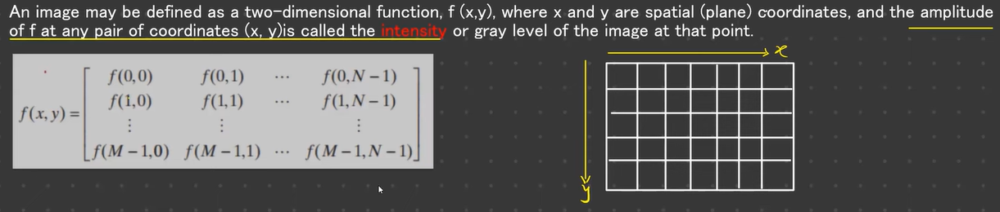

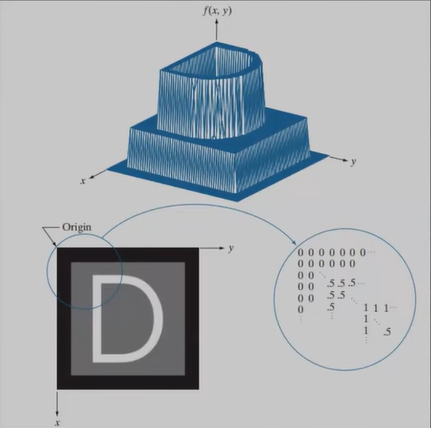

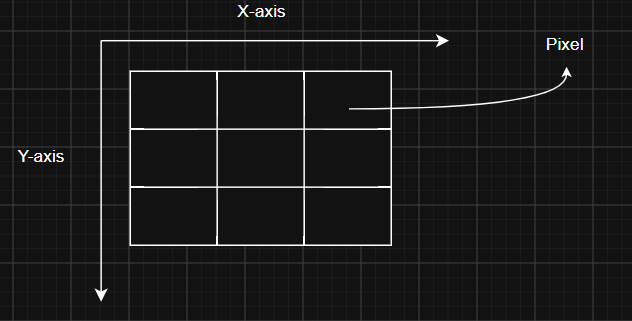

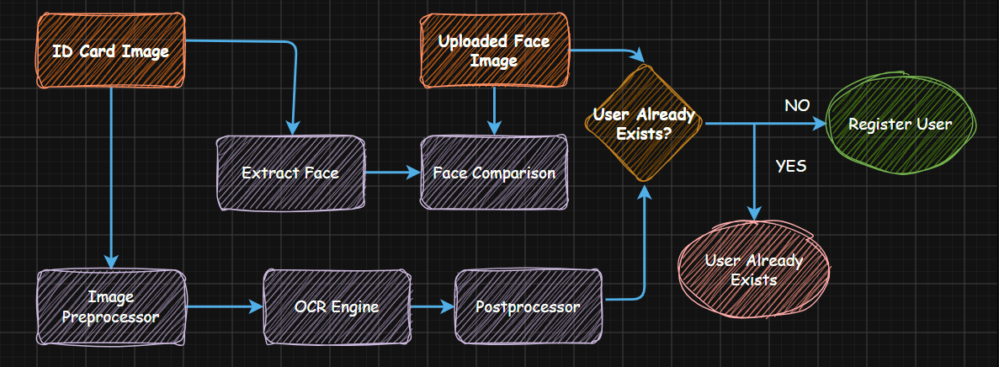

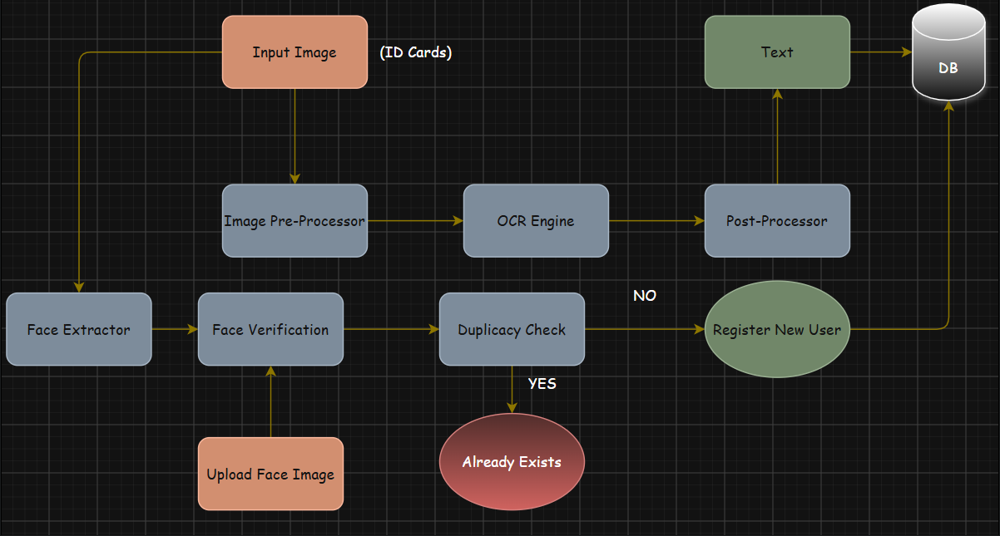

In [2]:
img = cv2.imread("A:/CODES/PROJECTS/eKYC/data/raw_data/RGBY.jpg")
img

array([[[ 38,   3,   0],
        [ 70,  12,   7],
        [ 96,   0,   0],
        ...,
        [  0,  20,  21],
        [  0,  20,  21],
        [  0,  20,  21]],

       [[ 65,   6,   4],
        [112,  29,  27],
        [152,  22,  22],
        ...,
        [118, 238, 237],
        [118, 239, 235],
        [118, 238, 237]],

       [[101,   0,   0],
        [160,  30,  30],
        [208,  29,  30],
        ...,
        [ 54, 246, 239],
        [ 54, 247, 237],
        [ 54, 246, 239]],

       ...,

       [[  0,  55,   0],
        [ 57, 163,  56],
        [ 35, 193,  27],
        ...,
        [ 16,   6, 250],
        [ 16,   6, 250],
        [ 16,   6, 250]],

       [[  0,  55,   0],
        [ 57, 163,  56],
        [ 35, 193,  27],
        ...,
        [ 16,   6, 250],
        [ 16,   6, 250],
        [ 16,   6, 250]],

       [[  0,  55,   0],
        [ 57, 163,  56],
        [ 35, 193,  27],
        ...,
        [ 16,   6, 250],
        [ 16,   6, 250],
        [ 16,   6, 250]]

In [3]:
# y-axis/Rows is 586, x-axis/Columns is 415 and 3 channels for BGR 
print(img.shape)
print("Top left", img[0, 0])
print("Top right", img[0, 414])
print("Bottom left", img[585, 0])
print("Bottom right", img[585, 414])

(586, 415, 3)
Top left [38  3  0]
Top right [ 0 20 21]
Bottom left [ 0 55  0]
Bottom right [ 16   6 250]


In [4]:
type(img) # image is read as numpy array

numpy.ndarray

Displaying an Image

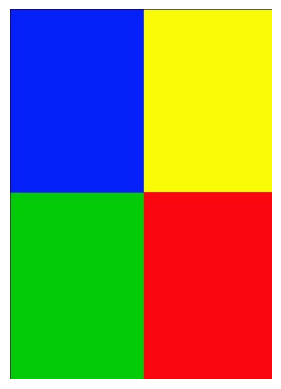

In [5]:
# OpenCV read in RGR but modern libraries like matplotlib reads in RGB.
rbg_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(rbg_img)
plt.axis("off")
plt.show()

Gray Scale Conversion: Converting the image to grayscale reduces the image to one intensity channel (no RGB channels) because it makes processing Faster and simpler.

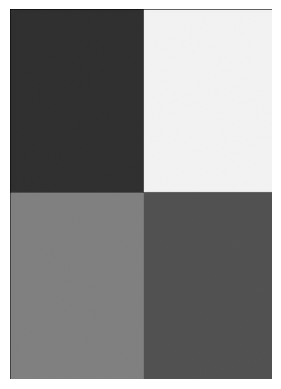

In [6]:
rbg_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(rbg_img, cmap="gray")
plt.axis("off")
plt.show()

Splitting and merging channels

In [7]:
blue = img[:, :, 0]
green = img[:, :, 1]
red = img[:, :, 2]

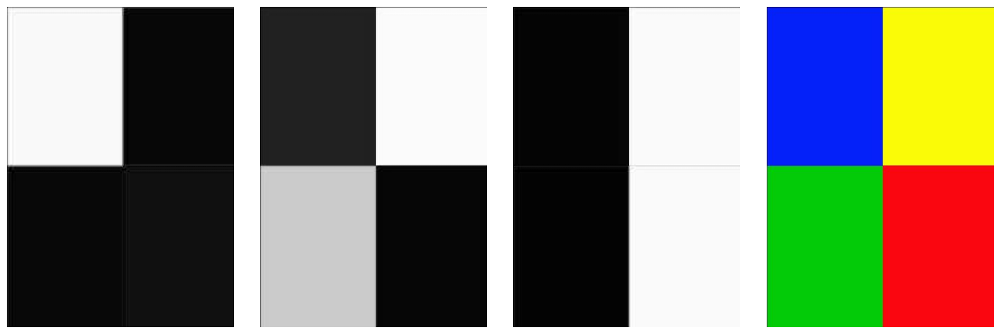

In [8]:
image_paths = [blue, green, red, img]
fig, axes = plt.subplots(1, len(image_paths), figsize=(15, 5))

for i, img in enumerate(image_paths):
    rbg_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(rbg_img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

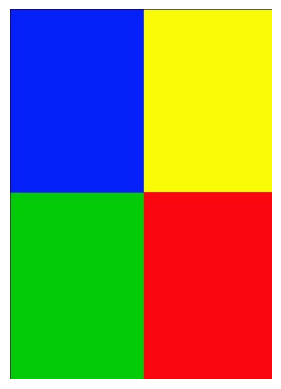

In [9]:
b, g, r = cv2.split(img)
rbg_img = cv2.merge((b, g, r))
rbg_img = cv2.cvtColor(rbg_img, cv2.COLOR_BGR2RGB)
plt.imshow(rbg_img)
plt.axis("off")
plt.show()

## **<font style="color:rgb(134,19,348)">Image Smoothing/ Blurring</font>**

[**Image smoothing and blurring**](https://cvexplained.wordpress.com/2020/05/26/smoothing-and-blurring/) in digital image processing is a technique that softens sharp edges and reduces high-frequency noise by averaging or blending pixel values with their neighbors. It reduces the details in an image by making color transitions between edges smooth instead of sudden, and by averaging out rapid pixel intensity changes.

**Types of Blurring Techniques:**
1. **Average/Mean (Box) Blur:** 
2. **Median Blur:** 
3. **Gaussian Blur:** 
4. **Bilateral Filter:** 

### **<font style="color:rgb(120,120,50)">Mean Blur</font>**

It is the simplest case of smoothing operation. This operation takes the average of the pixels and replace the central pixel with this average. Mean blur example using a 3 x 3 sampling window and keeping border values unchanged. `kernel` are of odd sizes because of the center pixel 

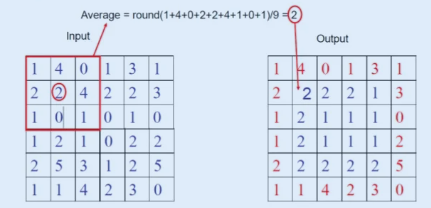

#### Original Image

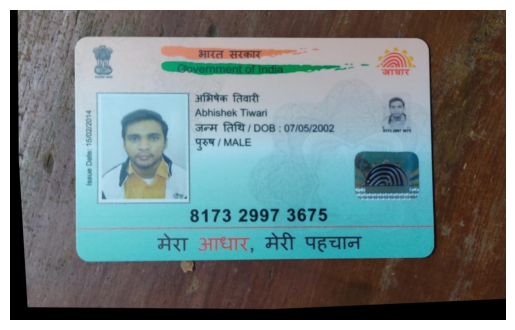

In [10]:
img = cv2.imread("A:/CODES/PROJECTS/eKYC/data/raw_data/sample_image1.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(img)
plt.axis('off')
plt.show()

#### Using Custom Kernel Function

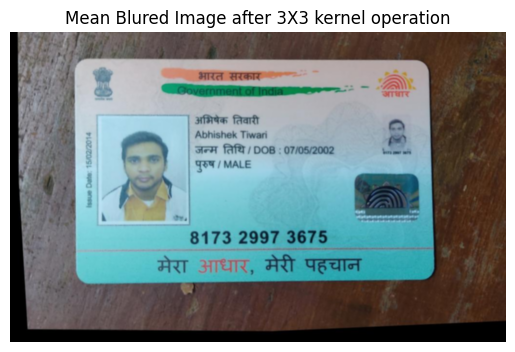

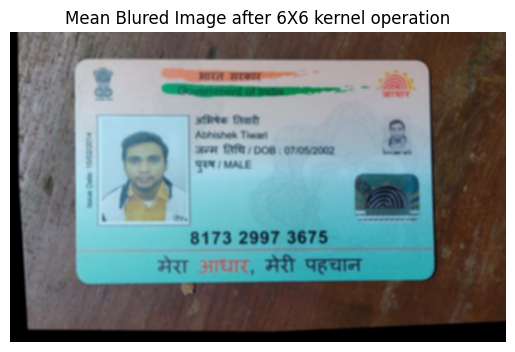

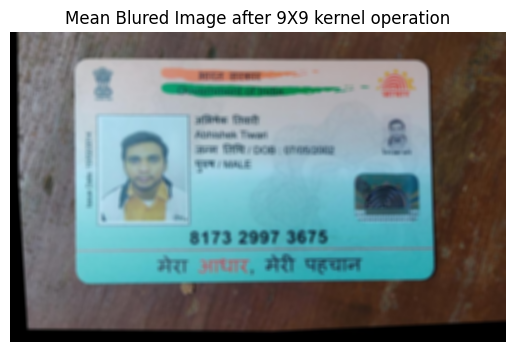

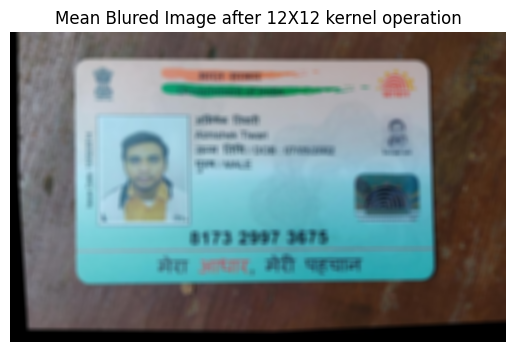

In [11]:
def meankernel(size):
    """
    creating mean filter kernel
    """
    return np.ones((size, size), dtype = np.float32)/(size**2)

for size in range(3, 14, 3): # kernel are generally of odd sizes because of the center pixel
    blur_img = cv2.filter2D(img , -1, meankernel(size))
    plt.figure()
    plt.imshow(blur_img)
    plt.title(f"Mean Blured Image after {size}X{size} kernel operation")
    plt.axis('off')
    plt.show()

#### Using `blur()`

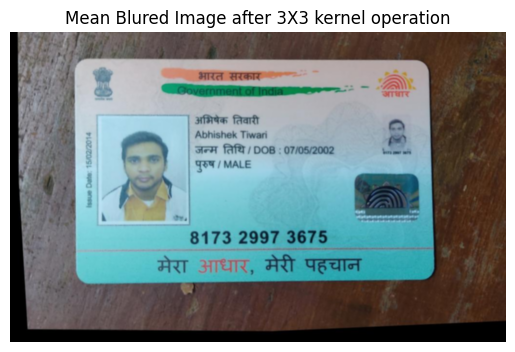

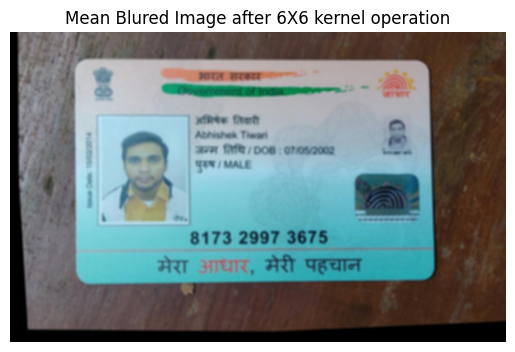

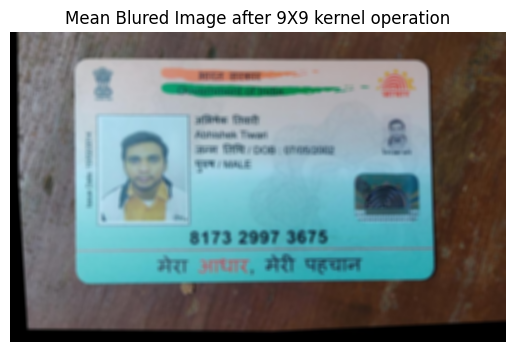

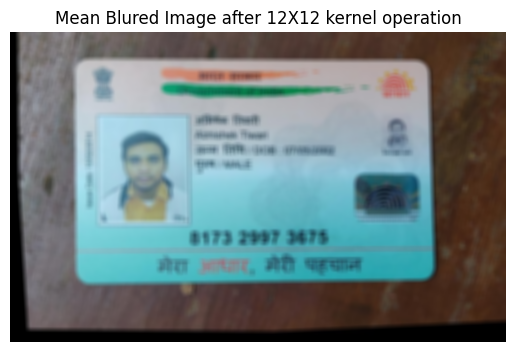

In [12]:
for size in range(3, 14, 3):
    blur_img = cv2.blur(img, (size, size))
    plt.figure()
    plt.imshow(blur_img)
    plt.title(f"Mean Blured Image after {size}X{size} kernel operation")
    plt.axis('off')
    plt.show()

### **<font style="color:rgb(120,120,50)">Gaussian Blur</font>**

It is a method of blurring the image through the use of Gaussian Function. 

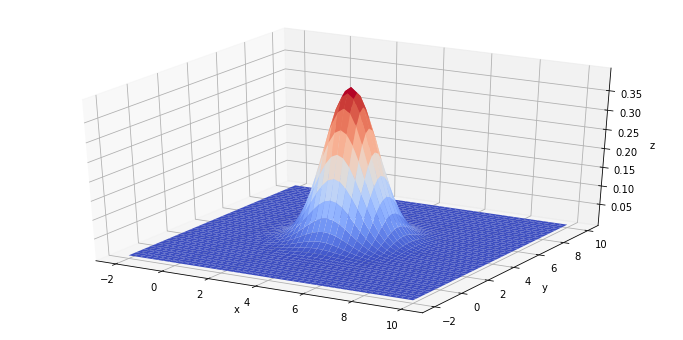

Imagine that this distribution is superimposed over a group of pixels in an image. It should be apparent looking at this graph, that if we took a weighted average of a pixel's values and the height of the curve at that point, the pixels in the center of the group would contribute most significantly to the resulting value.

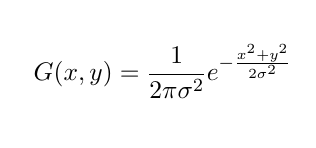

GaussianBlur generally work better (reduces noise without degrading image quality) than the mean filter because it gives more weight to the central pixels and less weight to the pixels that are further away.

#### Using Custom Kernel Function

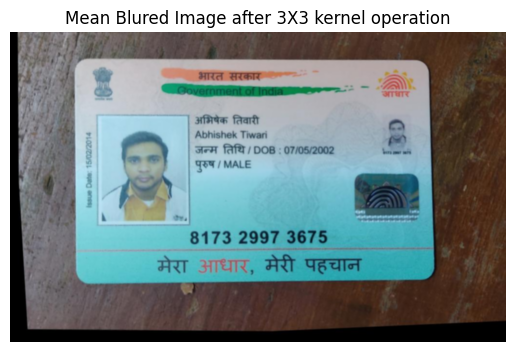

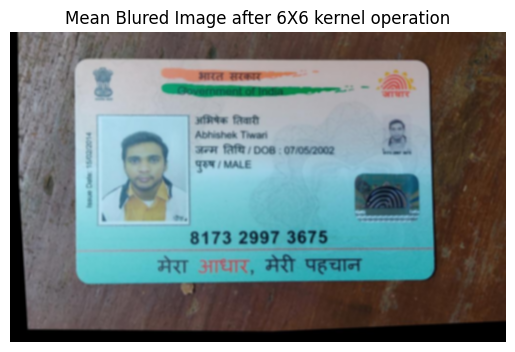

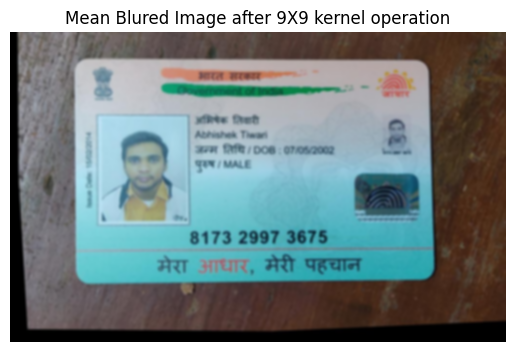

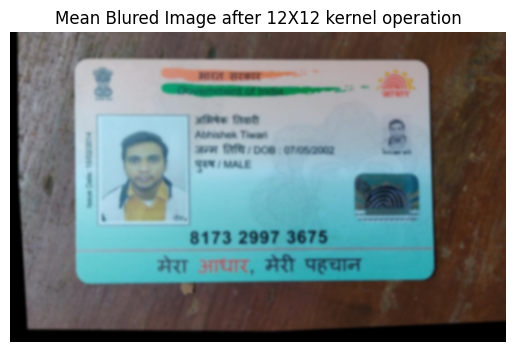

In [13]:
def gaussian_kernel(sigma, size):
    kernel = np.zeros((size, size))
    center = size // 2
    normalization_factor = 1 / (2 * np.pi * sigma**2)

    for i in range(size):
        for j in range(size):
            # x and y represent the distance of the current pixel from 
            # the center of the kernel in the horizontal and vertical directions, respectively.
            x = i - center
            y = j - center
            kernel[i, j] = normalization_factor*np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    # Normalize the kernel
    kernel /= np.sum(kernel)
    
    return kernel

for size in range(3, 14, 3):
    sigma = 2.5 # standard deviation of the Gaussian distribution of Gaussian Blurring
    blur_img = cv2.filter2D(img , -1, gaussian_kernel(sigma, size))
    plt.figure()
    plt.imshow(blur_img)
    plt.title(f"Mean Blured Image after {size}X{size} kernel operation")
    plt.axis('off')
    plt.show()

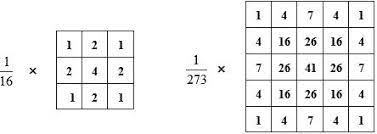

#### Using `GaussianBlur()`

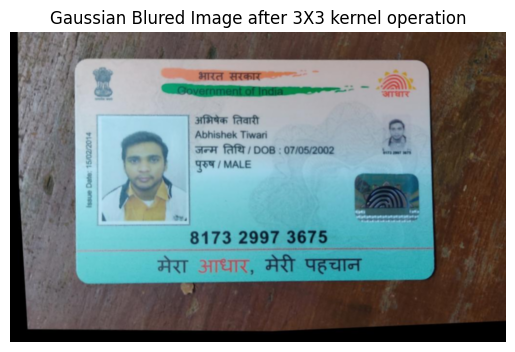

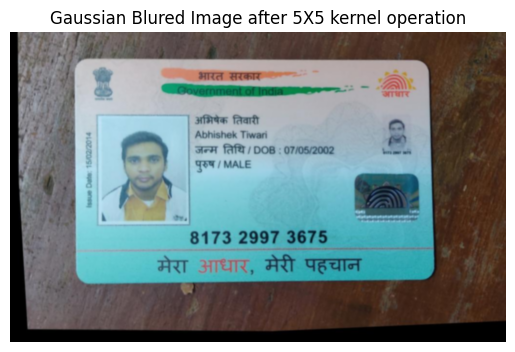

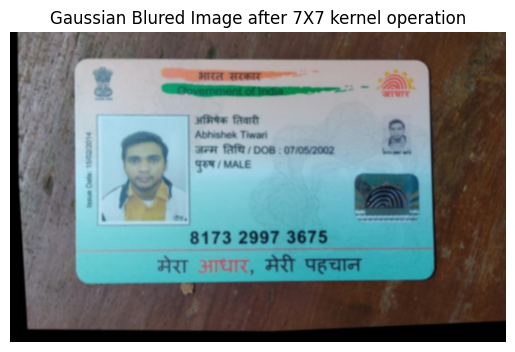

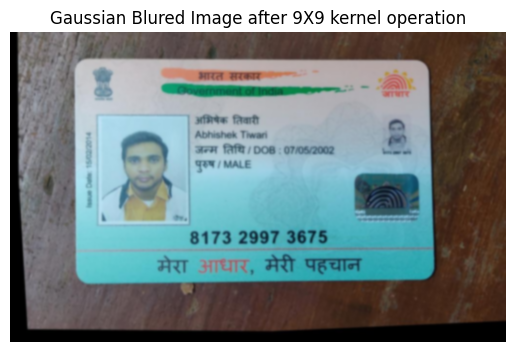

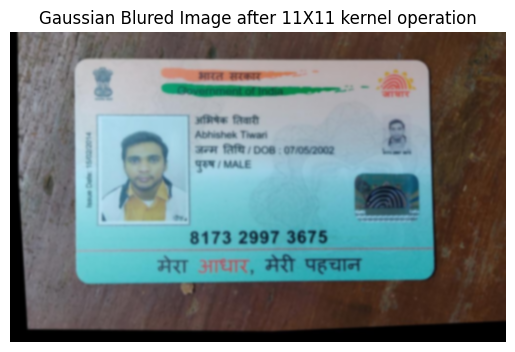

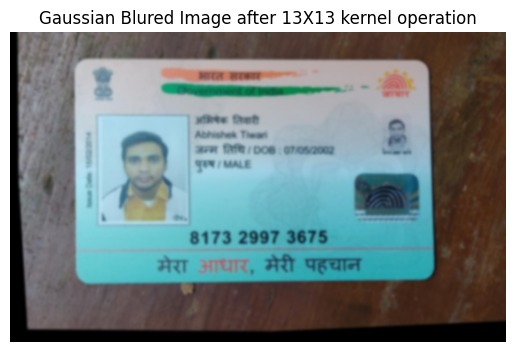

In [14]:
for size in range(3, 14, 2):
    plt.figure()
    plt.imshow(cv2.GaussianBlur(img, (size, size), 0))
    plt.title(f"Gaussian Blured Image after {size}X{size} kernel operation")
    plt.axis('off')
    plt.show()

## **<font style="color:rgb(134,19,348)">Histograms</font>**

You can consider histogram as a graph or plot, which gives you an overall idea about the intensity distribution of an image. It is a plot with pixel values(ranging from 0 to 255) in X-axis and corresponding number of pixels in the image on Y-axis.

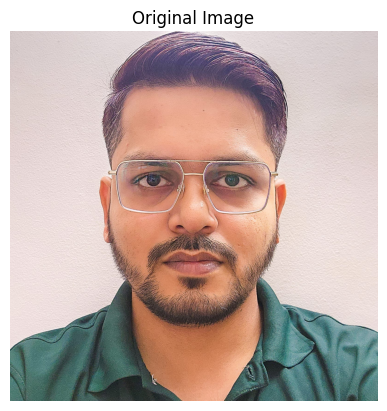

In [15]:
bgr_img = cv2.imread("A:/CODES/PROJECTS/eKYC/data/personal/bibek_face.jpg")
rbg_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(rbg_img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [16]:
rbg_img.shape, rbg_img.size # so, we have 1600 * 1589 * 3 number of pixels in the image.

((1600, 1589, 3), 7627200)

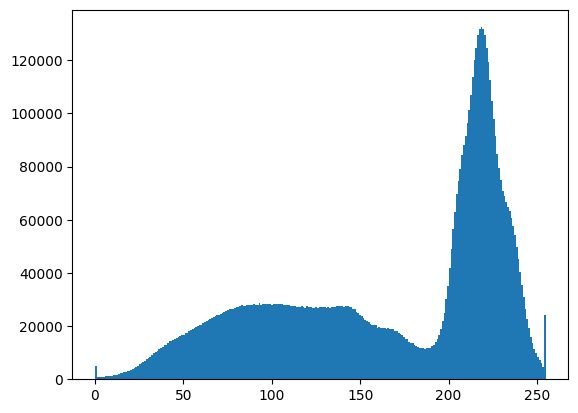

In [17]:
# Histograms
plt.hist(rbg_img.ravel(), bins=256, range=[0, 255])
plt.show()

high number of Higher pixel values in a image means there are more lighter colors in the image. And these lighter colors are background colors. So, we can also use this histogram to find the threshold value for image segmentation. Because generally the person have darker colors than the background.

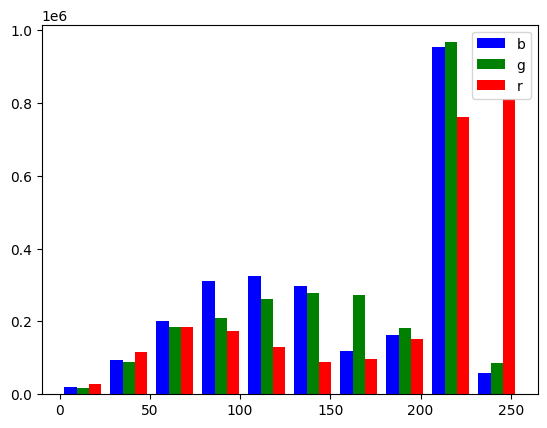

In [18]:
colors = ('b', 'g', 'r')
bgr_img_ravel = [bgr_img[:,:,0].ravel(), bgr_img[:,:,1].ravel(), bgr_img[:,:,2].ravel()]

plt.hist(bgr_img_ravel, color=colors, label=colors)
plt.legend()
plt.show()

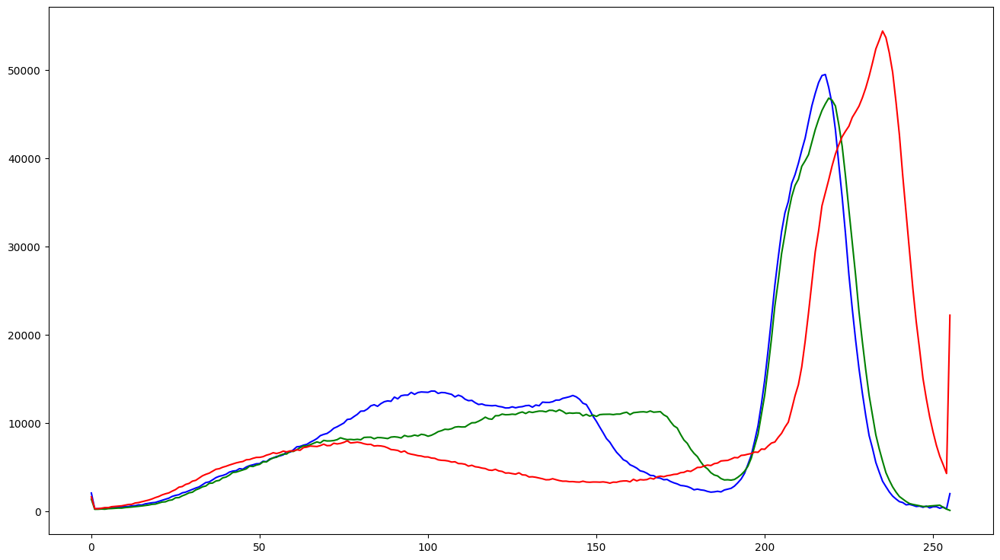

In [19]:
plt.figure(figsize=(16, 9))

for i, color in enumerate(colors):
    histogram = cv2.calcHist([bgr_img], [i], None, [256], [0, 256])
    plt.plot(histogram, color = color)

plt.show()

## **<font style="color:rgb(134,19,348)">Thresholding</font>**

Thresholding is the process of setting a specific cutoff value to convert continuous probability scores or feature map intensities into discrete binary or categorical decisions. Thresholding compares an input value (such as a pixel intensity or a network's output probability) against a set limit (T). If the value crosses the threshold, it is assigned to one class or state (e.g., 1 or foreground); if it does not, it is assigned to another (e.g., 0 or background). It is used for 

1. Image segmentation: segments an image into foreground and background regions based on pixel intensity.
2. Object Detection
3. Character Recognition
4. Binary and Multiclass Classification
5. Handling Model Uncertainty etc.

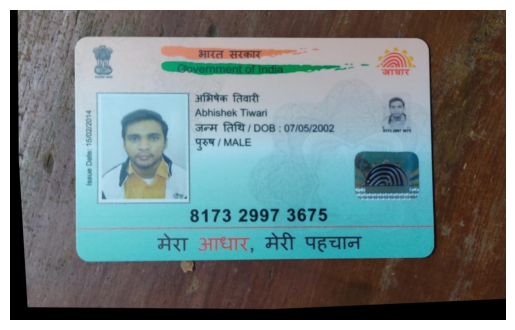

In [20]:
plt.imshow(img)
plt.axis("off")
plt.show()

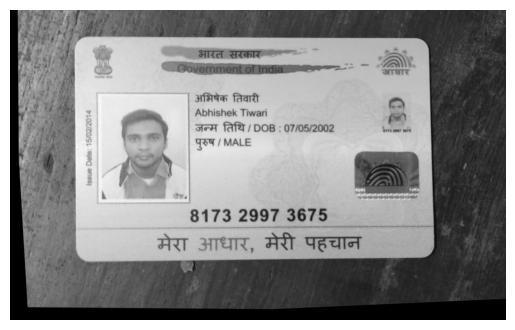

In [21]:
gray =  cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.show()

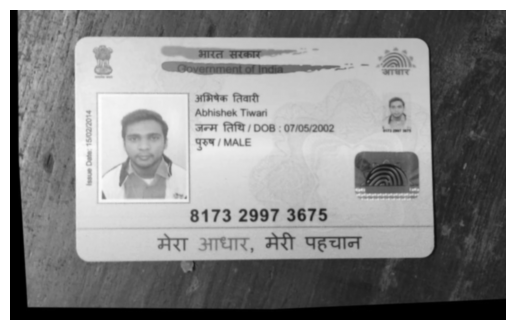

In [22]:
blurred =  cv2.GaussianBlur(gray, (5, 5), 0)
plt.imshow(blurred, cmap='gray')
plt.axis("off")
plt.show()

### **<font style="color:rgb(120, 120, 50)">Simple Thresholding</font>**

Where you have to manually supply threshold value.
 Applying simple thresholding methods requires human intervention. We must specify a threshold value T. All pixel intensities below T are set to 255. And all pixel intensities greater than T are set to 0.

After the image is blurred, we compute the thresholded image using **`cv2.threshold`** function. This method requires four arguments.
1. The **grayscale image** that we wish to threshold. We supply our blurred image as the first.
2. **T threshold value**
3. The **output value** applied during thresholding. Any pixel intensity p that is greater than T is set to zero and any p that is less than T is set to the output value:
4. A **thresholding method** like **`cv2.THRESH_BINARY`**, **`cv2.THRESH_BINARY_INV`**, etc.

**`cv2.THRESH_BINARY_INV`** method, which indicates that pixel values p less than T are set to the **output value**. Your segmented objects to appear as **white on a black background**. Use it if images's background is bright and faces are dark.

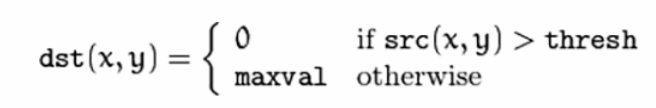

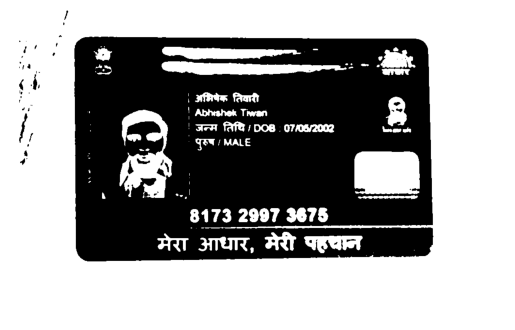

In [23]:
# cv2.THRESH_BINARY_INV: IF pixels are greater than 150, then replace them with 0 (black) else replace them with 255 (white)
# cv2.THRESH_BINARY: IF pixels are greater than 150, then replace them with 255 (white) else replace them with 0 (black)
T, threshInv =  cv2.threshold(blurred, 150, 255, cv2.THRESH_BINARY_INV)
plt.imshow(threshInv, cmap='gray')
plt.axis("off")
plt.show()

**`cv2.THRESH_BINARY`** method, which indicates that pixel values p greater than T are set to the **output value**. Your segmented objects to appear as **black on a white background**. Use it if images's background is dark and faces are brighter.

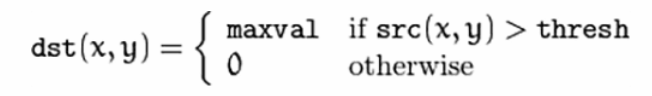

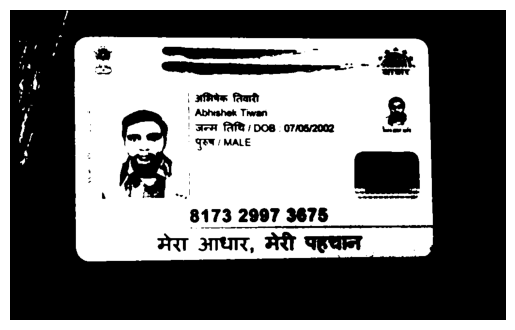

In [24]:
T, thresh =  cv2.threshold(blurred, 150, 255, cv2.THRESH_BINARY)
plt.imshow(thresh, cmap='gray')
plt.axis("off")
plt.show()

### **<font style="color:rgb(120,120,50)">Otsu Thresholding</font>**


In the previous section on simple thresholding we needed to manually supply a threshold value of T. For simple images in controlled lighting conditions, it might be feasible for us to hardcode this value.

But in real-world conditions where we do not have any a priori knowledge of the lighting conditions, that is why we use Otsu's method where threshold value of T got automatically computed.

**Otsu Thresholding:** The algorithm analyzes the image's intensity histogram (the distribution of pixel brightness values). It searches for a threshold value that separates pixels into two distinct classes—usually the foreground and the background. It finds the optimal threshold by minimizing the intra-class (within-group) variance or, equivalently, maximizing the inter-class (between-group) variance. It makes the assumption that the grayscale histogram of our pixel intensities of our image is bi-modal, which simply means that the histogram is two peaks.

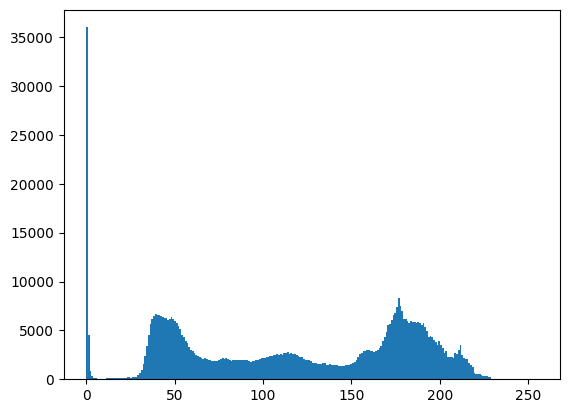

In [25]:
plt.hist(gray.ravel(), bins=256, range=[0, 255])
plt.show()

Notice how the histogram clearly has two peaks — the first sharp peak corresponds to the uniform background color of the image, while the second peak corresponds to the card region itself.

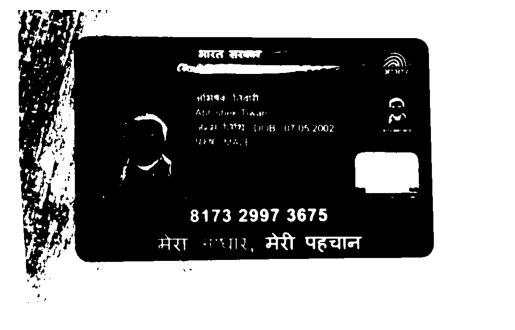

[INFO] otsu's thresholding value: 114.0


In [26]:
(T, otsu_threshInv) = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
plt.imshow(otsu_threshInv, cmap='Greys_r')
plt.axis("off")
plt.show()

print("[INFO] otsu's thresholding value: {}".format(T))

### **<font style="color:rgb(120,120,50)">Adaptive Thresholding</font>**

Goal in adaptive thresholding is to statistically examine local regions of our image and determine an optimal value of T for each region — which begs the question: Which statistic do we use to compute the threshold value T for each region?

It is common practice to use either the arithmetic mean or the Gaussian mean of the pixel intensities in each region (other methods do exist, but the arithmetic mean and the Gaussian mean are by far the most popular).

In the arithmetic mean, each pixel in the neighborhood contributes equally to computing T. And in the Gaussian mean, pixel values farther away from the (x, y)-coordinate center of the region contribute less to the overall calculation of T.

Here, we have two **adaptiveMethod** options: **cv2.ADAPTIVE_THRESH_MEAN_C** and **cv2.ADAPTIVE_THRESH_GAUSSIAN_C** methods.

**blockSize**: Size of the pixel neighborhood (e.g., 3, 5, 7, 11...). It defines the local region matrix (N × N) used to calculate the threshold. It must be an odd integer greater than 1. Example: 11.

**C**: A constant subtracted from the computed mean or weighted mean. It acts as a fine-tuning offset; a positive value filters out background noise/artifacts. Example: Here, 2 is the tunning parameter which is subtracted from the mean or weighted mean calculated.

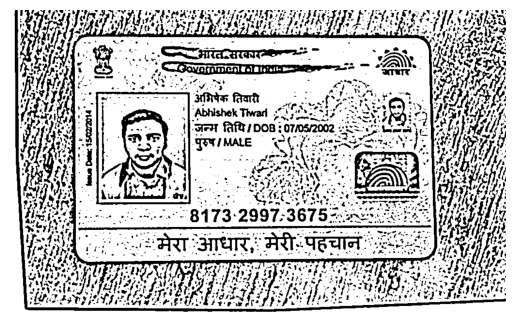

In [ ]:
adp_thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

plt.imshow(adp_thresh, cmap='Greys_r')
plt.axis("off")
plt.show()

Even though the background and foreground of the image countain a lots of noise, but we are able to find the boarder of the ID card.

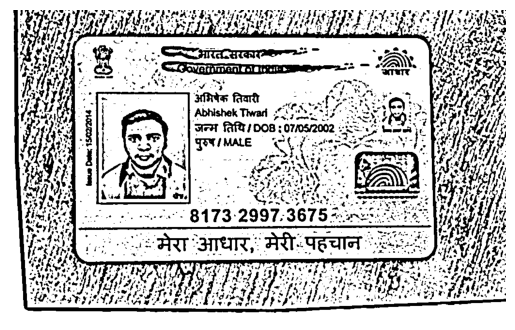

In [28]:
adp_thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 2)

plt.imshow(adp_thresh, cmap='Greys_r')
plt.axis("off")
plt.show()

## **<font style="color:rgb(134,19,348)">Edge Detection</font>**

An edge is a location in an image where there is a rapid change in intensity. We convert a 2D image in a set of points where image intensity changes rapidly. Lastly, we plot white version of these detected edges on a black image. Edges are very much important in terms of converging or capturing visual information of the image.

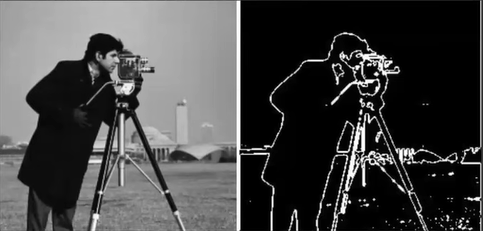

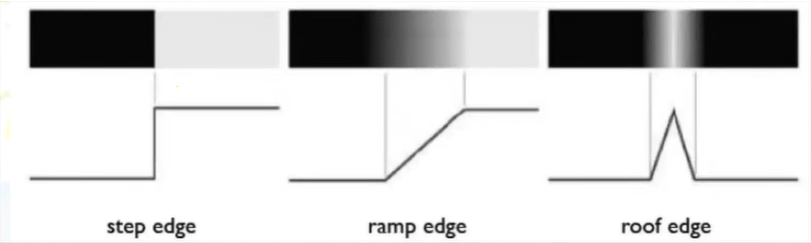

### Edge Detection Using **Gradient**

Gradient is rate of change for any function. The local maxima and local minima of the gradient function are the edges of the image. Here, we take modulus of the gradient of intensity function of the image.

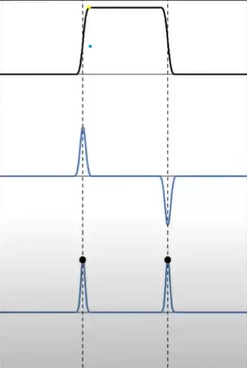

We need strength and direction of the gradient to find the edges.

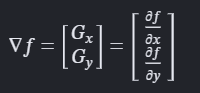

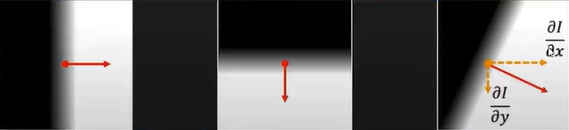

`[δI/δx, δI/δy] = [finite, 0]` `[δI/δx, δI/δy] = [0, finite]` `[δI/δx, δI/δy] = [finite, finite]`

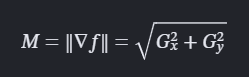

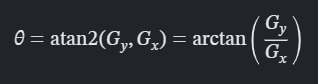

Since, the pixel are discrete, we use below formula to find the gradient of the image.
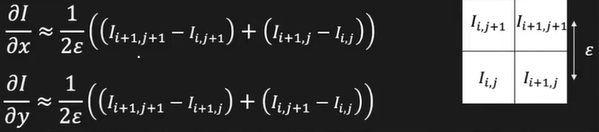

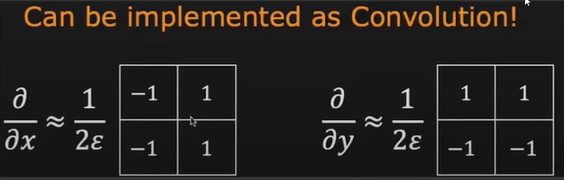

**Sobel Filter**: The Sobel operator is a classic discrete differentiation filter used in image processing and computer vision to detect edges by calculating an approximation of the image intensity gradient.

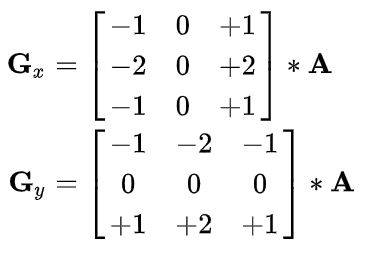

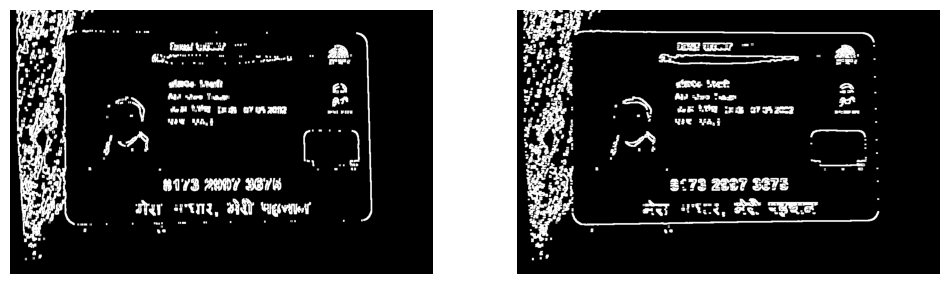

In [29]:
# Sobel Edge Detection
sobelx = cv2.Sobel(src=otsu_threshInv, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=5) # Sobel Edge Detection on the X axis 
sobely = cv2.Sobel(src=otsu_threshInv, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=5) # Sobel Edge Detection on the Y axis

# Convert to 8-bit
sobelx = cv2.convertScaleAbs(sobelx)
sobely = cv2.convertScaleAbs(sobely)

# Binary threshold
_, sobelx_bw = cv2.threshold(sobelx, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, sobely_bw = cv2.threshold(sobely, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

images = [sobelx_bw, sobely_bw]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, image in zip(axes, images):
    ax.imshow(image, cmap='gray')
    ax.axis('off')

plt.show()

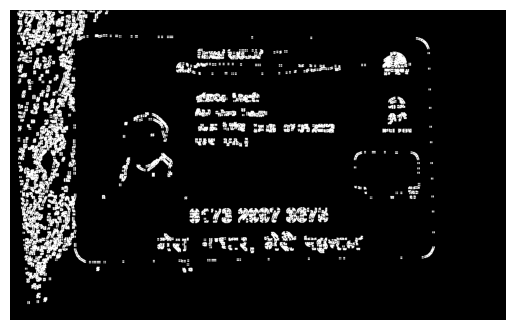

In [30]:
sobelxy = cv2.Sobel(src=otsu_threshInv, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection
sobelxy = cv2.convertScaleAbs(sobelxy)

_, sobelxy_bw = cv2.threshold(sobelxy, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(sobelxy_bw, cmap='gray')
plt.axis('off')
plt.show()

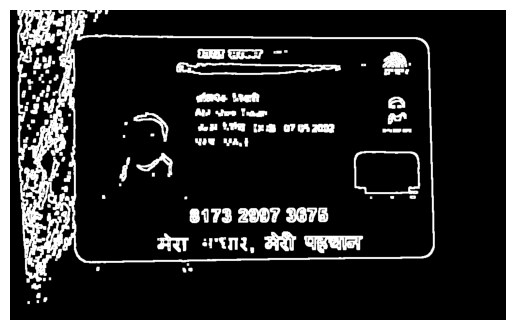

In [31]:
magnitude = cv2.magnitude(sobelx.astype(np.float32), sobely.astype(np.float32))
magnitude = cv2.convertScaleAbs(magnitude)

_, sobelxy_bw = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(sobelxy_bw, cmap='gray')
plt.axis('off')
plt.show()

### Edge Detection Using **Laplacian**

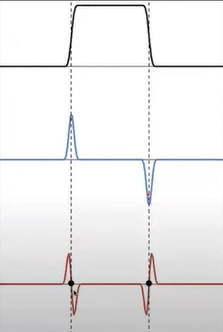

### Edge Detection Using **Canny Edge Detection**

Steps involved in Canny Edge Detection:
1. **Noise Reduction**: It is compulsory to remove noise from the image before procceding further in Canny Edge Detection.
2. **Intensity Gradient Calculation of the Image**
3. **Supression of False Edges**: Non-Maximum Suppression of edges to filter out unwanted pixels (which may not actually constitute an edge). To accomplish this, each pixel is compared to its neighboring pixels. If the gradient magnitude of the current pixel is greater than the magnitudes of its neighbors, it is retained as a potential edge pixel; otherwise, it is suppressed (set to zero). This step helps in thinning the edges and retaining only the most significant ones.
4. **Double Thresholding** or **Hysteresis Thresholding**: 
    - If the gradient magnitude value is higher than the larger threshold value, those pixels are associated with solid edges and are included in the final edge map.
    - If the gradient magnitude values are lower than the smaller threshold value, the pixels are suppressed and excluded from the final edge map.
    - All the other pixels, whose gradient magnitudes fall between these two thresholds, are marked as 'weak' edges (i.e. they become candidates for being included in the final edge map).
    - If the 'weak' pixels are connected to those associated with solid edges, they are also included in the final edge map.

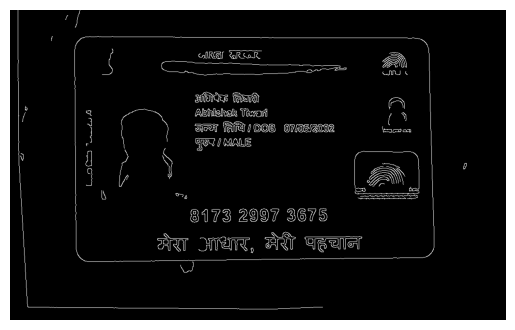

In [32]:
edges = cv2.Canny(image=blurred, threshold1=100, threshold2=200)

plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

## **<font style="color:rgb(134,19,348)">Contour Detection</font>**

**Contour** is a boundary around something that has well defined edges, so the machine is able to calculate difference in gradient, and form a recognisable shape through continuing change and draw a boundary around it.

When we join all the points on the boundary of an object, we get a contour. Typically, a specific contour refers to boundary pixels that have the same color and intensity. Countour Detection internally uses Edge Detection to find the contours.

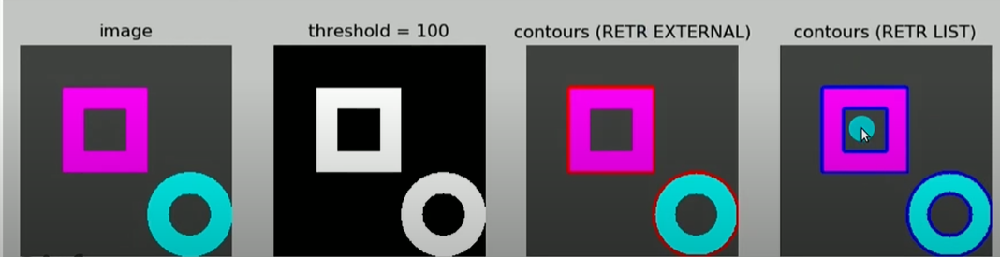

**<font style="color:rgb(120,120,50)">Retrieval Modes</font>**

Function **`cv2.findContours()`** does not only returns the contours found in an image but also returns valuable information about the hierarchy of the contours in the image. The hierarchy encodes how the contours may be arranged in the image, e.g, they may be nested within another contour. Often we are more interested in some contours than others. For example, you may only want to retrieve the external contour of an object.

Using the Retrieval Modes specified, the **`cv2.findContours()`** function can determine how the contours are to be returned or arranged in a hierarchy.  For more information on Retrieval modes and contour hierarchy [Read here](https://docs.opencv.org/4.1.0/d9/d8b/tutorial_py_contours_hierarchy.html).

Some of the important retrieval modes are:
- **`cv2.RETR_EXTERNAL`** - retrieves only the external contours (contours that form the extreme outer boundary).
- **`cv2.RETR_LIST`** - retrieves all of the contours without establishing any hierarchical relationships.
- **`cv2.RETR_TREE`** - retrieves all of the contours and reconstructs a full hierarchy of nested contours. The hierarchy represents the relationship between contours, such as parent-child relationships.
- **`cv2.RETR_CCOMP`** - retrieves all of the contours and organizes them into a two-level hierarchy. At the top level, there are **external** boundaries of the components. At the second level, there are boundaries of the **holes**. If there is another contour inside a hole of a connected component, it is still put at the top level.
- **`cv2.RETR_FLOODFILL`** - retrieves contours by the flood-fill algorithm.

**<font style="color:rgb(120,120,50)">Compression Methods</font>**

Detected contours can be compressed to reduce the number of points. In this sense, OpenCV provides sevaral methods to reduce the number of points. This can be set with the parameter method.

- **`CHAIN_APPROX_SIMPLE`**: This is faster, approximates the contour and compresses horizontal, vertical, and diagonal segments, keeping only their end points.

- **`CHAIN_APPROX_NONE`**: This retains all the original contour points, making it suitable when precise contour representation is required, but it might be slower and consume more memory compared to CHAIN_APPROX_SIMPLE.

In [ ]:
contours, _ = cv2.findContours(adp_thresh, mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE)

# assuming the ID card is the largest contour object in the image
largest_contour = max(contours, key=cv2.contourArea, default=None)
if largest_contour is not None:
    largest_area = cv2.contourArea(largest_contour)
else:
    largest_area = 0


x, y, w, h = cv2.boundingRect(largest_contour)

print("contours", (x, y, w, h))
print("Area", largest_area)

contours (133, 54, 743, 466)
Area 335490.5


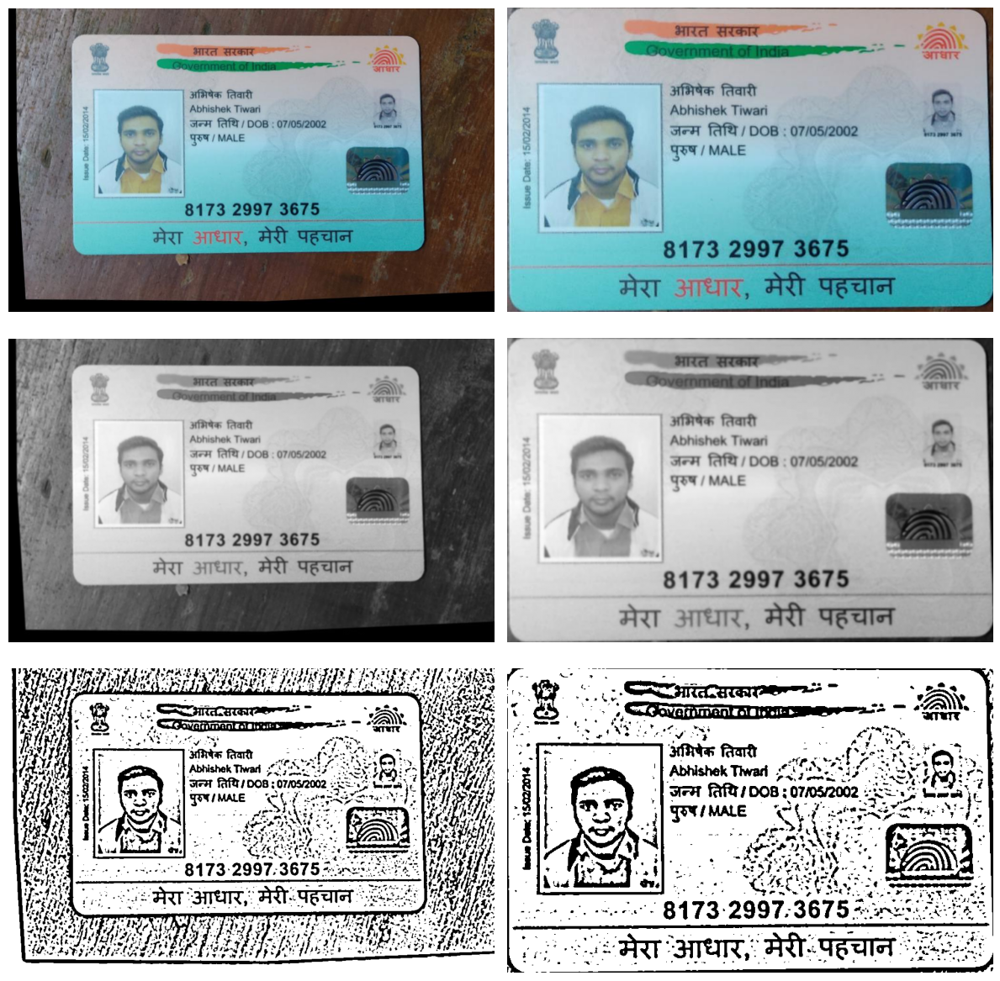

In [42]:
# ploting the original image and the detected countour image side by side
image_paths = [
    img, img[y:y+h, x:x+w],
    blurred, blurred[y:y+h, x:x+w],
    adp_thresh, adp_thresh[y:y+h, x:x+w]
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for ax, image in zip(axes.ravel(), image_paths):
    ax.imshow(image, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [54]:
cv2.imwrite("A:/CODES/PROJECTS/eKYC/data/personal/sample_image1.jpg", cv2.cvtColor(img[y:y+h, x:x+w], cv2.COLOR_RGB2BGR))

True

## **<font style="color:rgb(134,19,348)">Face Detection using Haar-Cascade</font>**

Haar Cascade is a feature-based object detection algorithm to detect objects from images. A cascade function is trained on lots of positive and negative images for detection. It uses the cascade function and cascading window. It tries to calculate features for every window and classify positive and negative. If the window could be a part of an object, then positive, else, negative. It perfroms two tasks `Classification` (Face is present or not) and `Localization` (Bounding box around the face). Identifying given object in an image is known as object detection. We will use Haar Cascade pre-trained XML files. It's the simplest way to to perform object detection. It can’t be used for face recognition since it only identifies the matching shape and size. It's more like binary classifier, as it assigns positive to those cascade windows that can be a part of our object.

The [OpenCV library manages a repository on GitHub](https://github.com/opencv/opencv/tree/4.x/data/haarcascades) for all popular `haar cascades pre-trained` xml files that can be used for various object detection tasks, for example:

- Human face detection
- Eye detection
- Vehicle detection
- Nose / Mouth detection
- body detection
- license plate detection

### **It has 4 components**

#### 1. **<font style="color:rgb(120,120,50)">Haar Features</font>**

<!-- https://youtu.be/q2oDd5kX3Wo?si=OgEibX14-pesbzUv -->


The Viola-Jones algorithm uses a set of features similar to Haar wavelets, which are a set of square-shaped functions. More specifically, the algorithm uses three types of Haar-like features represented in the following figure:

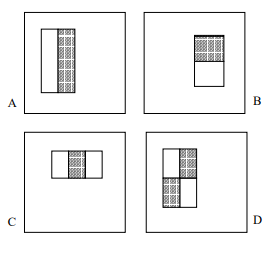

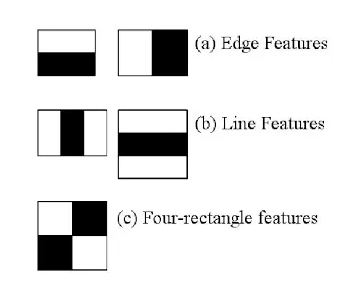

Edge Features: Detect edges of an object. Smallest scale- 1x2 or 2x1.
Line Features: Detect lines and highlights within an object. Smallest scale- 1x3 or 3x1.
Four-Rectangle Features: Detect diagonal edges and lines. Smallest scale- 2x2

Each feature specifies a set of rectangles in the image window. A rectangle can be marked as white or black. The feature value is computed as the difference between the sum of the pixel values in the white areas and the sum of pixel values in the black areas.

The feature value will be around zero for “flat regions”, i.e., where all the pixels have the same value. A large feature value will be obtained in the regions where the pixels in the black and white rectangles are very different.

- Think of Haar features as shapes that can catch the shadows and bright spots on a face. For example, the area around your eyes might be darker compared to your cheeks. Haar features can notice this by comparing the dark and light areas.

- These features use patterns of blocks, some white and some gray, to check different parts of a picture. Each pattern is like a special magnifying glass that looks for certain shadows or lights. For instance:

    - A pattern might look for the shadow under your nose by comparing the bright area of your cheeks to the darker area just below your nose.
    - Another pattern might notice the area around your eyes is darker than the area on your forehead.
- The entire reason of using these features to comapare the "white-ness" and "black-ness" of neighboring pixels.
- It uses a 24x24 window as the base window size to start evaluating these features in any given image.
- If we consider all possible parameters of the haar features like position, scale and type we end up calculating about 160,000+ features in this window (24x24).

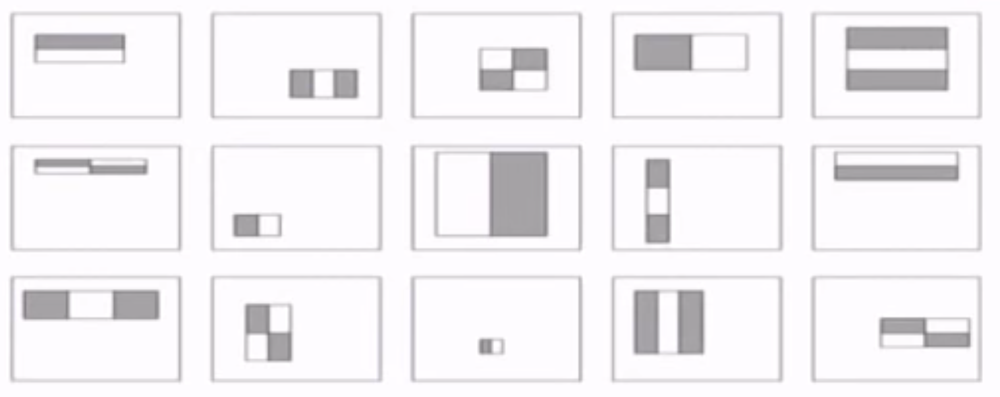


Suppose this is the gray scale representation of an image

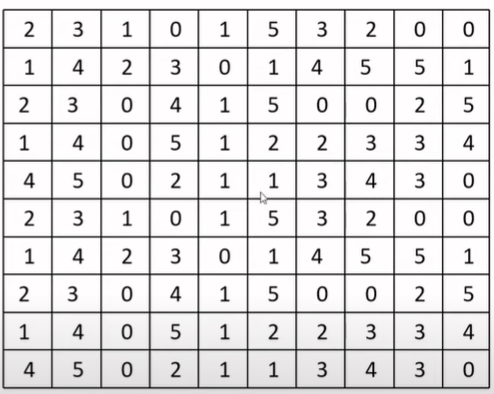

We need to calculate the deltas like this, sliding through all part of the image

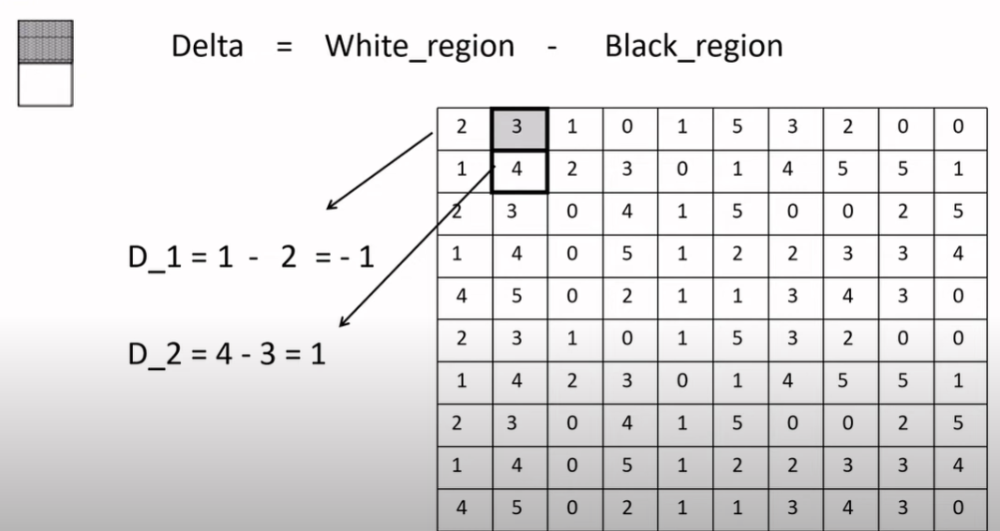

Every Haar feature is suitable at particular location. Our aim is to find highest delta for particular Haar feature.

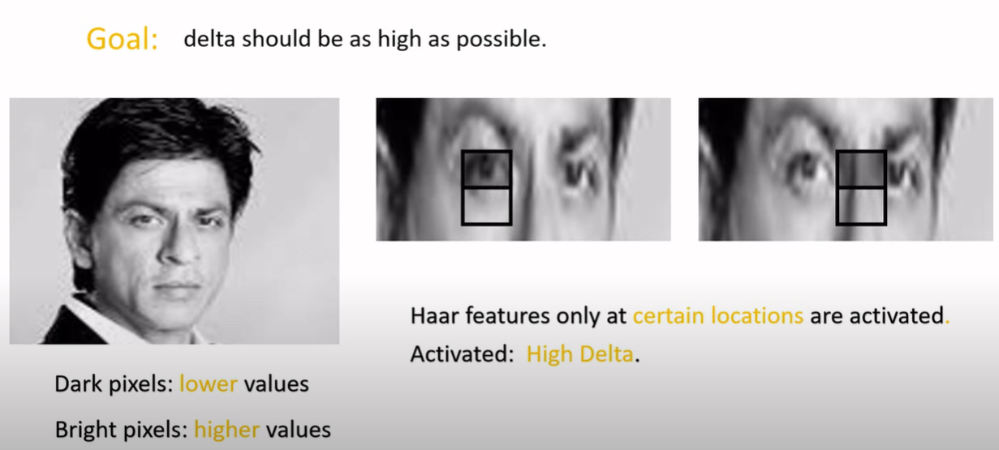

#### 2. **<font style="color:rgb(120,120,50)">Integral Image</font>**


The integral image is a data structure for efficiently computing the sum of pixel values in a rectangular image window. Hence, the Haar-like features can be computed very quickly using the integral image representation.
Each point in the integral image is a sum of the pixels above and left of the corresponding pixel in the source image. A precomputed image that allows for fast calculation of the sum of pixel values in any rectangular region.


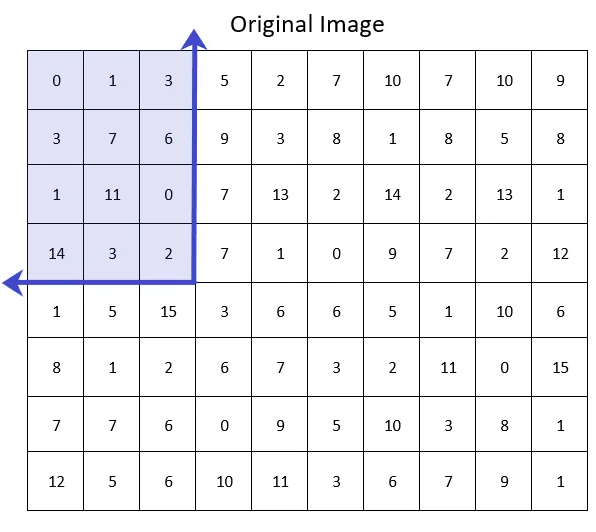

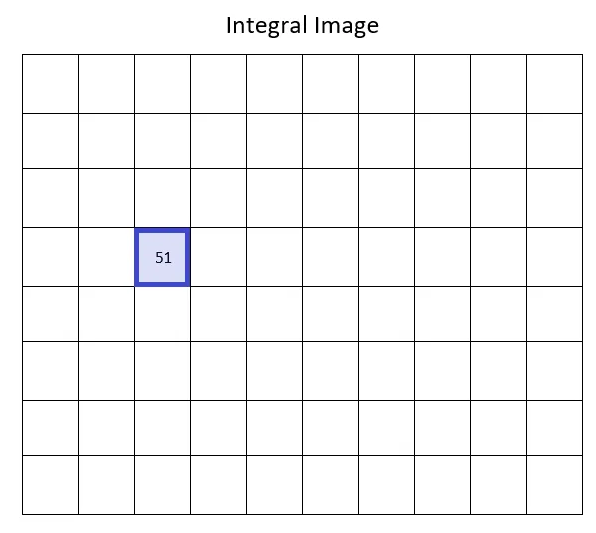


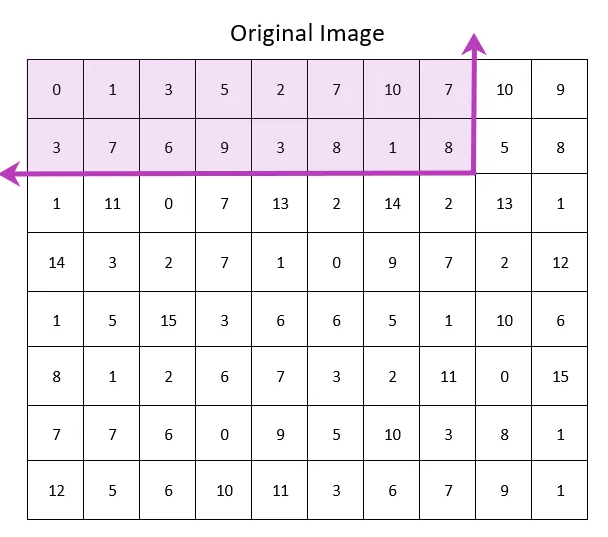

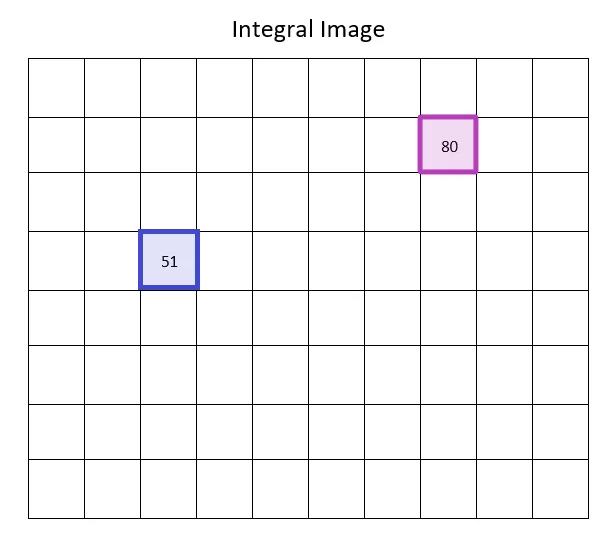

A cell in the Integral image corresponds to a specific area in the original image. The value of that cell is the sum of all the values in that corresponding area in the original image. Now that we have a little bit of intuition for how an Integral mage is made and organized, let’s fill out the rest of it.

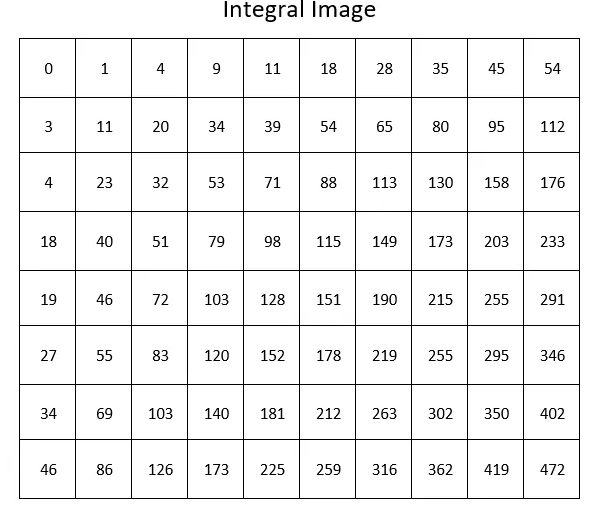

Now, go back to the original image. We’re going to select a portion of the image that we want to find the sum of and we’ll outline it in red.

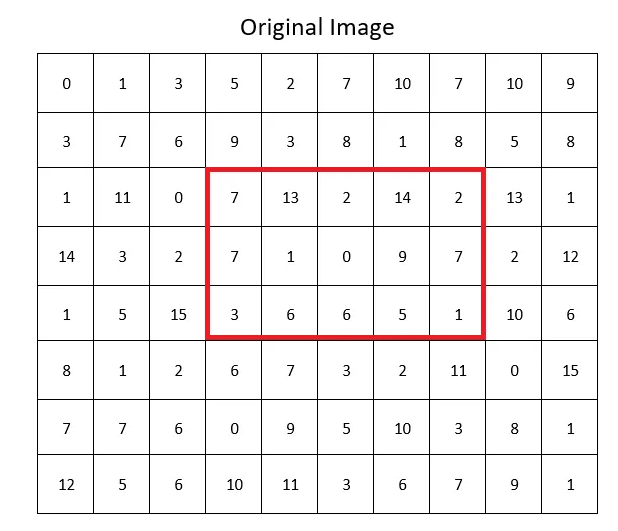

We can get the sum using below integral image,

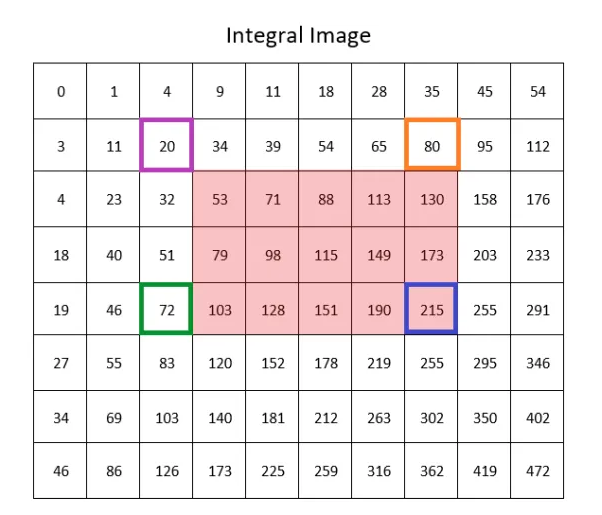

sum = (215+20) - (72+80) = 83

https://levelup.gitconnected.com/the-integral-image-4df3df5dce35

#### 3. **<font style="color:rgb(120,120,50)">Adaboost Algorithm</font>**

Boosting refers to any Ensemble method that can combine several weak learners into a strong learner. The general idea of most boosting methods is to train predictors sequentially, each trying to correct its predecessor. AdaBoost also known as Adaptive Boosting is one of the most popular Boosting techniques used.

One way for a new predictor to correct its predecessor is to pay a bit more attention to the training instances that the predecessor under-fitted. This results in new predictors focusing more and more on the hard cases. This is known as Adaptive Boosting. For example, to build an Adaptive Boosting classifier, a first base classifier (such a Decision Tree or SVM classifier) is trained and used to make predictions on the training set. The relative weights of the misclassified predictions are altered and increased in order to lay more emphasis on these predictions while making the next predictor. A second classifier is trained using the updated weights and again it makes predictions on the training set, weights are updated and so on. Once all the predictions are trained, the ensemble method makes predictions very much like boosting except the predictors have different weights depending on their overall accuracy on the weighted training set. The drawback of this type of algorithm is that it cannot be parallelized thereby increasing time required. Thus after successfully running AdaBoost on all the features we are left with the most relevant features required for detection. Therefore, this reduces computational time as we don’t have to go through all the features and is much more efficient.

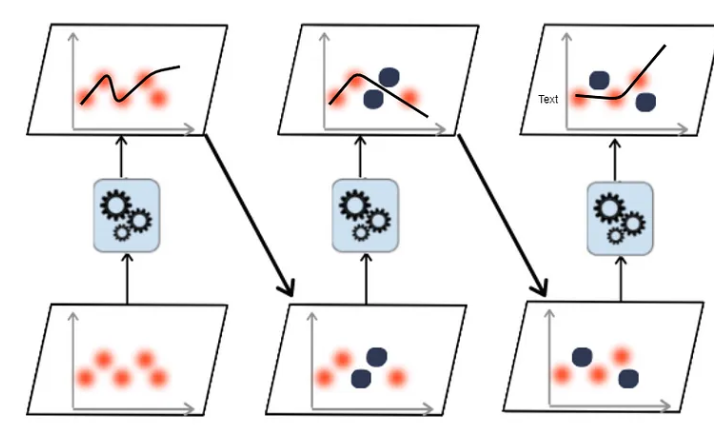

#### 4. **<font style="color:rgb(120,120,50)">Cascade Filters</font>**

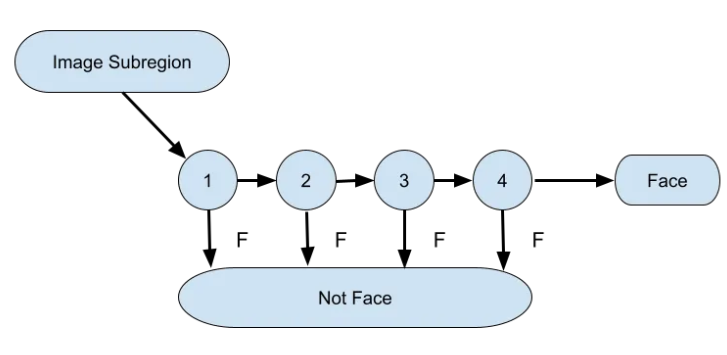

In simple terms, each feature acts as a binary classifier in a cascade filter. If an extracted feature from the image is passed through the classifier and it predicts that the image consists of that feature then it is passed on to the next classifier for next feature existence check otherwise it is discarded and next image is checked. This thereby decreases computation time as we have to check only some features in windows where the object is not present rather than checking all features.

### **<font style="color:rgb(120,120,50)">Steps Breaking Down</font>**

https://youtu.be/ZSqg-fZJ9tQ?si=eSwecEEq0Zj6vHWK

**`face_cascade = cv2.CascadeClassifier(<XML_cascade_path>)`**

This initializes a cascade classifier object using OpenCV's *`CascadeClassifier`* class. A cascade classifier is a machine learning-based model trained to detect objects in images. In this case, this classifier trained specifically to detect human faces. The *`XML_cascade_path`* variable should contain the path to the XML file that defines the cascade classifier model.

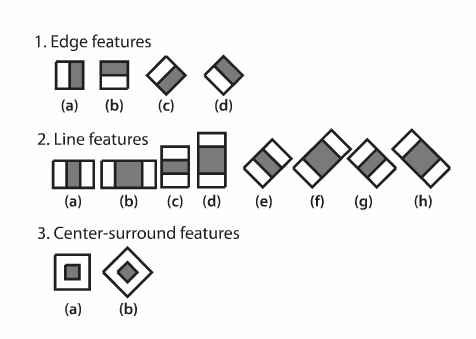

**`faces = face_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5)`**

The primary purpose of detectMultiScale is to detect objects of interest (e.g., faces) at multiple scales within an image. Objects can appear at different sizes due to variations in distance, perspective, or image resolution. By processing the image at multiple scales, the algorithm increases the likelihood of detecting objects of varying sizes.

Internally, detectMultiScale employs a sliding window approach. It moves a rectangular window (often referred to as a "window" or "detector") across the image at different positions and scales. At each position and scale, the classifier evaluates whether the contents of the window resemble the target object (e.g., a face). The classifier is trained to recognize patterns and features indicative of the object being detected.

- *`scaleFactor`*: This parameter specifies how much the image size is reduced at each image scale. It helps in the detection of faces at different scales. A smaller scaleFactor value increases the chance of detecting faces but also increases computation time. A value of 1.1 means the algorithm is trying to detect faces at slightly different scales by resizing the input image by 10% at each step.

    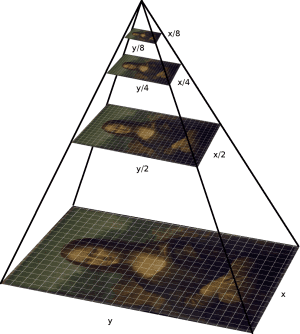

- *`minNeighbors`*: This parameter specifies how many neighbors each candidate rectangle should have to retain it. Higher values result in fewer detections but with higher quality. A lower value will detect more faces but might also include false positives. A value of 5 indicates that a candidate rectangle should have at least 5 neighbors to be considered a valid detection.




In [ ]:
gray_img = cv2.cvtColor(contour_id, cv2.COLOR_BGR2GRAY)

# Load the Haar cascade classifier model
face_cascade = cv2.CascadeClassifier("A:\CODES\PROJECTS\eKYC\models\haarcascade_frontalface_default.xml")

# Detect faces in the image
faces = face_cascade.detectMultiScale(gray_img, scaleFactor=1.1, minNeighbors=5)

# faces
# Find the face with the largest area
max_area = 0
largest_face = None
for (x, y, w, h) in faces:
    area = w * h
    if area > max_area:
        max_area = area
        largest_face = (x, y, w, h)

# Extract the largest face
if largest_face is not None:
    (x, y, w, h) = largest_face
    # extracted_face = img[y:y+h, x:x+w]
    
    # Increase dimensions by 15%
    new_w = int(w * 1.50)
    new_h = int(h * 1.50)
    
    # Calculate new (x, y) coordinates to keep the center of the face the same
    new_x = max(0, x - int((new_w - w) / 2))
    new_y = max(0, y - int((new_h - h) / 2))

    # Extract the enlarged face
    extracted_face = contour_id[new_y:new_y+new_h, new_x:new_x+new_w]

plt.imshow(extracted_face)
plt.axis('off')
plt.show()

In [ ]:
cv2.imwrite("A:/CODES/PROJECTS/eKYC/data/raw_data/extracted_face.jpg", extracted_face)

## **<font style="color:rgb(134,19,348)">Face Comparison/Face Recognition</font>** Using `Face_recognition` and `Dlib`

**Face Comparison**
- **Definition**: A one-to-one (1:1) process that checks if two specific images show the same person.
- **Function**: It answers the question, "Do these two photos match?"
- **Use Case**: Unlocking a phone with a selfie or comparing a live photo to an ID card during digital onboarding.

**Face Recognition**
- **Definition**: A one-to-many (1:N) process that searches for a face inside a large database of many enrolled or unknown people.
- **Function**: It answers the question, "Who is this person?"
- **Use Case**: Identifying a person in a crowd, tagging friends on social media, or scanning a security watchlist.

**`Dlib`**: Dlib is a C++ library with Python bindings, known for its excellent face detection and shape prediction capabilities. It also includes a pre-trained face recognition model.

**`Face_recognition`**: This Python library is built on top of dlib and provides a simple API for face recognition tasks. It offers both face detection and recognition functionalities. Face_recognition (128-dimensional) has less dimension than `Deepface` (4096-dimensional).

In [ ]:
old_face = face_recognition.load_image_file("A:/CODES/PROJECTS/eKYC/data/faces/old_face.jpg")
old_face = cv2.cvtColor(old_face, cv2.COLOR_BGR2RGB)

new_face = face_recognition.load_image_file("A:/CODES/PROJECTS/eKYC/data/faces/new_face.jpg")
new_face = cv2.cvtColor(new_face, cv2.COLOR_BGR2RGB)

#--Converting image into encodings
old_face_encode1 = face_recognition.face_encodings(old_face)[0]
new_face_encode2 = face_recognition.face_encodings(new_face)[0]

In [ ]:
print(face_recognition.compare_faces([old_face_encode1], new_face_encode2)[0])

**`Face Encoding`**: Each detected and aligned face is encoded into a numerical representation, typically a high-dimensional feature vector. This encoding captures unique facial characteristics, such as the arrangement of facial landmarks, texture, and shape.

**`Similarity Metric`**: To determine if two face encodings represent the same person or different individuals, a similarity metric is applied. Commonly used metrics include Euclidean distance or cosine similarity. These metrics calculate the distance or similarity between two feature vectors.

## **<font style="color:rgb(134,19,348)">Text Extraction using OCR</font>**

**Optical Character Recognition (OCR)** is an advanced AI method that automatically detects, extracts, and converts text inside images or scanned documents into editable, machine-readable digital data. Use cases of OCR includes Automated Data Entry, License Plate Recognition (LPR), Real-Time Translation, Archiving and Search, Accessibility for visually impaired individuals, etc.
Examples are **EasyOCR**, **Keras-OCR**, **PyTesseract**, **PaddleOCR**, **Tesseract v5** etc.

**EasyOCR**, **Keras-OCR**, **PyTesseract** and **PaddleOCR** uses CRNN (CNN + RNN) while **Tesseract v5** uses LSTM (Long Short-Term Memory).

It take image with text in it and returns **position**, **text** and **confidence score** of the text detected in the image.

Steps involved in OCR:
1. **Text Detection**: helps to identify the regions in the image where text is present.
2. **Text Recognition**: passes the image with bounding boxes around the text and pass the cropped image to the OCR engine to extract the text and confidence score.

OCR is a technology used to convert different types of documents, such as scanned paper documents, PDF files, or images captured by a digital camera, into editable and searchable data. The primary function of OCR is to recognize text within these documents and convert it into a machine-readable form.

**`Uses of OCR:`**

`Document Digitization:` OCR is widely used to digitize printed documents, converting them into editable formats. This is particularly useful for archiving and retrieving information without manually inputting data.

`Business Process Automation:` In business environments, OCR streamlines processes by automating the data extraction from physical documents such as invoices, receipts, and forms, thus reducing the need for manual entry and improving accuracy.

`Accessibility:` OCR technology helps visually impaired individuals by converting written content into spoken words using text-to-speech technologies, thus making information more accessible.

`Translation and Language Recognition:` OCR can be used to translate documents by first converting scanned text to digital text, which can then be processed by translation software.

`Search and Retrieval:` OCR makes it possible to search for specific texts within a large volume of scanned documents, which is useful in legal, medical, and academic fields.

`Traffic and License Plate Recognition:` In the public safety sector, OCR technology is employed to automatically read vehicle license plates for traffic management and security purposes.

By converting static images of text into editable formats, OCR plays a critical role in numerous applications, enhancing efficiency and accessibility across various industries.

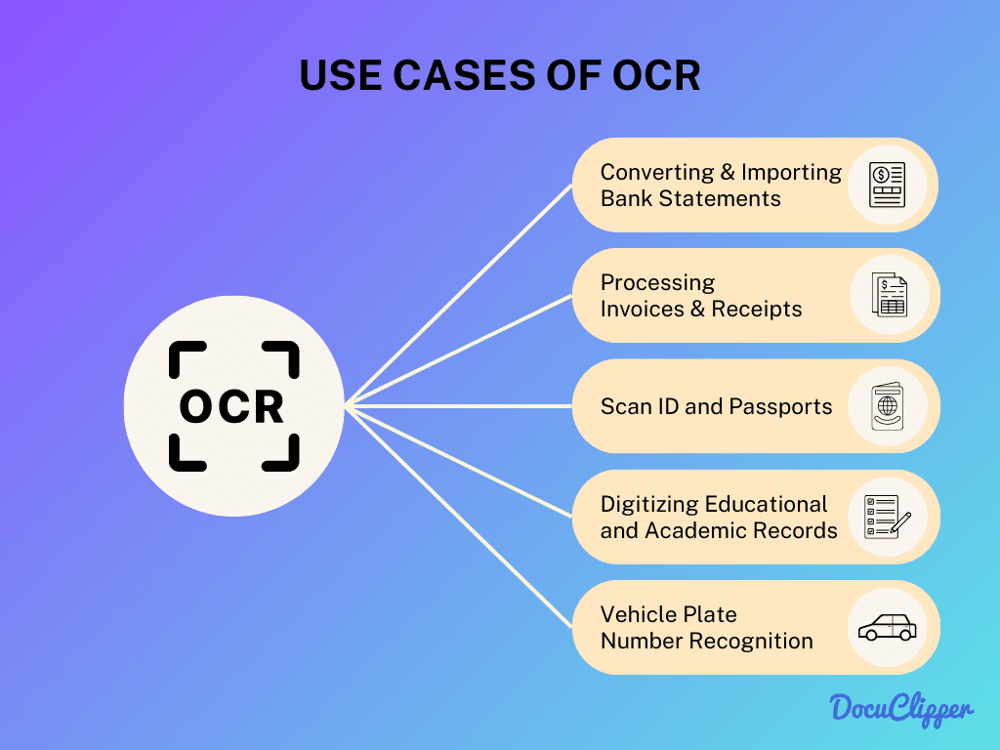

### OCR Engine

Text extraction can be achieved in two steps, i.e., `text detection` and `text recognition` or by training a single model to achieve both text detection and recognition.

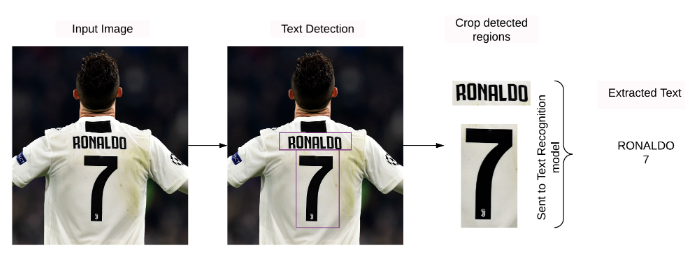

*`Text detection`* helps identify the region in the image where the text is present.  It takes in an image as an input, and the outputs bounding boxes.

*`Text recognition`* extracts the text from the input image using the bounding boxes obtained from the text detection model. It takes in an image and some bounding boxes as inputs and outputs some raw text.

Text detection is very similar to the object detection task where the object which needs to be detected is nothing but the text. We can use algorithms like RCNN, Faster-RCNN, SSD, YOLO etc.
Here, we will mainly focus on explaining the CRNN-CTC network for text recognition.

#### Text Recognition Pipeline

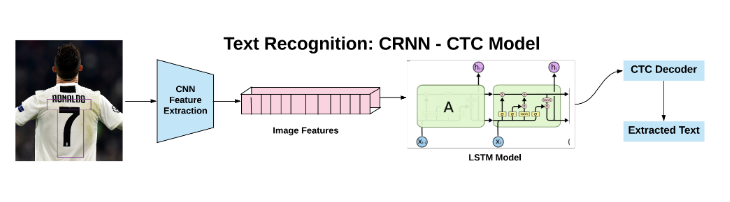


After the text detection step, regions, where the text is present, are cropped and sent through convolutional layers to get the features from the image. Later these features are fed to many-to-many LSTM architecture, which outputs softmax probabilities over the vocabulary.  These outputs from different time steps are fed to the CTC decoder to finally get the raw text from images.

**`CNN Features and Receptive Field`**


In CNN the kernel slides over the original image pixel by pixel and does some
math calculations to get the values of the new “convolved” image on
the next layer. The area of the image that the filter convolves is called
the `receptive field`. 

In the initial layers, the receptive field is small because each output feature only sees a small patch of the input image directly through the filter applied.
As you progress deeper into the network, each layer aggregates the information from previous layers, expanding the area of the input image that influences the output features. Thus, deeper layers have a larger receptive field and capture more global information rather than local details

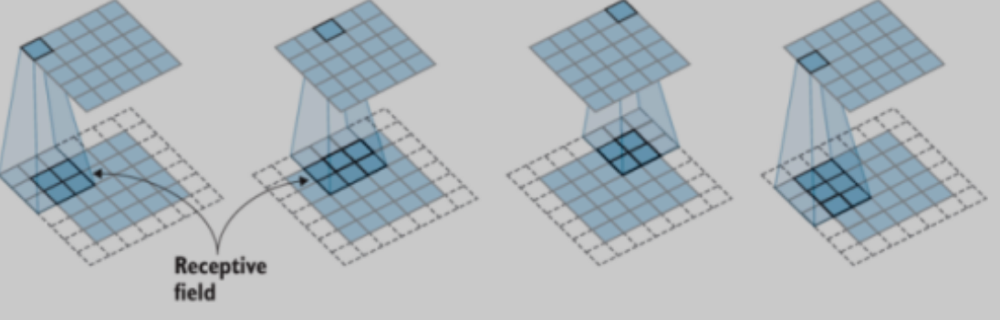


A grayscale image with width 128 and height 32 is sent through a series of convolutional & max-pooling layers.  Layers are designed in such a manner that we obtain feature maps of the shape   (None,  1,  31,  512) .  "None" here is nothing but the batch size which could take any value. 

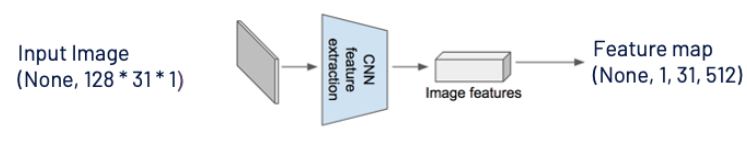

In convolutional networks, you look at an image through a smaller window and move that window to the right and down. That way you can find features in that window, for example a horizontal line or a vertical line or a curve etc… What exactly a convolutional neural network considers an important feature is defined while learning.

Wherever you find those features, you report that in the feature maps. A certain combination of features in a certain area can signal a larger, more complex feature exists there.

For example, your first feature map could for example looks for curves. The next feature map could look at a combination of curves that build circles. The next feature map could detect a bicycle from lines and circle features.

**`CNN Features to LSTM Model`**

(None,  1,  31,  512)  can be easily reshaped to   (None,  31,  512) , and 31 corresponds to the number of time steps, and 512 is nothing but the number of features at every time step.  One can relate this to training any LSTM model with word embeddings like word2vec, Glove, fastText, and the input shape is usually like  (batch_size, no_time_steps, word_embedding_dimension).

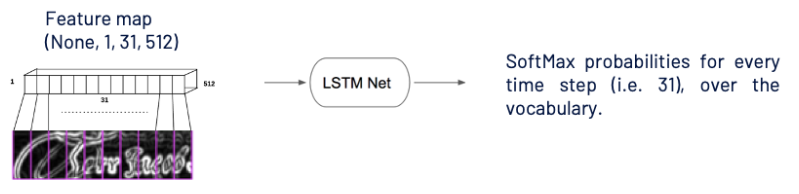


Feature maps coming from CNN layers are fed to the LSTM model, as shown above.  You might be thinking now that LSTM models are known to work with sequential data and how feature maps are sequential!!  Receptive fields play a significant role here. As one can see from the above image first value(first row, first column) in the feature map has visibility on the left part of the input image and last value(first row, last column) has visibility on the end part of the image, and yes this is sequential !!
From the LSTM model for every time step i.e., 31, we get a softmax probability over vocabulary.  Now let us move on to the exciting part, calculating the loss value for this architecture setup.

**`CTC(Connectionist Temporal Classification) Loss`**

CTC loss is a popular method used in machine learning for training sequence-to-sequence models, especially when the alignment between the inputs and the outputs is unknown. It's particularly useful in tasks like speech recognition, handwriting recognition, and other forms of sequence prediction where the timing of the output labels relative to the input sequence is not predefined.

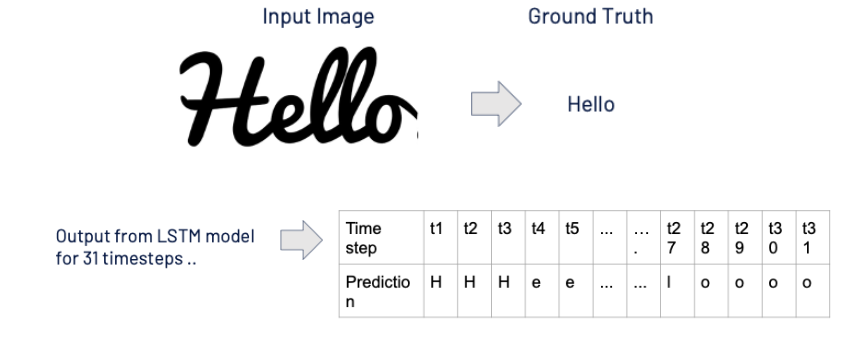

The length of ground truth is 5, which is not equal to the length of prediction i.e., 31.

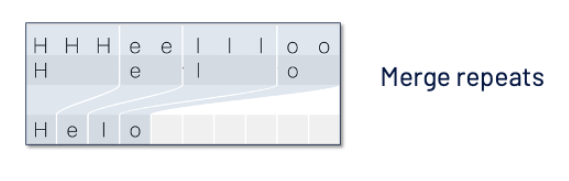

If we merge the repeats, we lose the repetitions, as shown in the above image.  With just merging, we end up with a single letter "l," which was supposed to be "ll." So a special character called "blank character" is introduced to avoid this. 

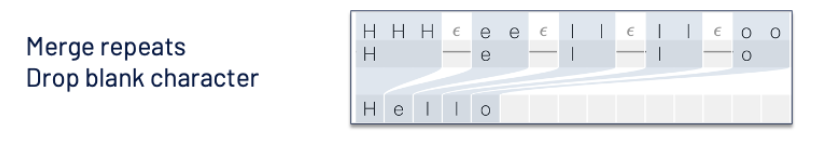

Now the decode operation consists of 2 steps:
1. Merge repeats 
2. Remove blank characters. 
Now you can see "ll," which is retained. 

For simplicity lets say,
the vocabulary is  { A, B, - } 

we have predictions for 3-time steps from LSTM network (SoftMax probabilities over vocabulary at  t1, t2, t3 )


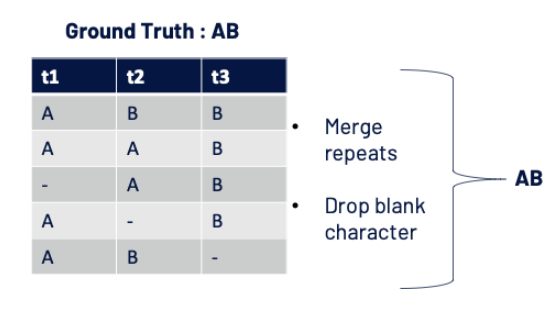

Let us say the Softmax probabilities for 3-time steps are as below:

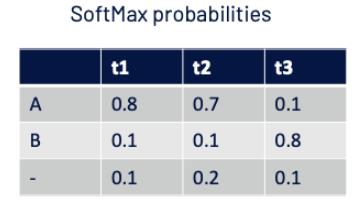

Loss is calculated as  - log(Probability of getting ground truth) 
Probability of getting GT AB:  = P(ABB) + P(AAB) + P(-AB) + P(A-B) + P(AB-)
Score for one path: AAB  =  (0.8 x 0.7 x 0.8)  and similarly for other paths. 



Creating an OCR engine is a challenging research task and
requires great knowledge in image processing, feature
extraction and machine learning. However, there are several
open source projects that provide OCR framework and are
widely used in the creation of OCR-related applications. In
order not to reinvent the wheel and also to save time for
development

> **NOTE:** Create different environments for each OCR due to dependency issues.

Also, we need to save the pre-processed image before text detection because OCR don't use numpy array as input and need local pathn.

### OCR using pytesseract

https://medium.com/@tejpal.abhyuday/trocr-transformer-based-optical-recognition-model-811f7b3217da

**`Installation Stesps:`**
1. https://pyimagesearch.com/2021/08/16/installing-tesseract-pytesseract-and-python-ocr-packages-on-your-system/
2. https://github.com/tesseract-ocr/tessdoc

Pytesseract is very fast.

`Tesseract Configuration (custom_config)`

--oem 3: Sets the OCR Engine Mode to 3, which means Tesseract will use both its LSTM and legacy engines to process the image. This is typically used to get the most accurate results.

--psm 3: Sets the Page Segmentation Mode to 3, indicating that Tesseract should treat the image as a single uniform block of text. This mode assumes a single column of text of variable sizes.

-l eng+osd: Specifies the language models to be used. Here, eng is for English, and osd is for orientation and script detection, which helps in determining text direction.

--tessdata-dir "A:/CODES/PROJECTS/eKYC/models/tessdata/": Directs Tesseract to use a specific directory for its training data files. This is useful when you have custom training data or multiple versions of tessdata.

-c tessedit_char_whitelist=abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789: This restricts the characters Tesseract will recognize to alphanumeric characters (both upper and lower case). This is useful for filtering out any symbols or punctuation marks that are not needed.

In [ ]:
# import pytesseract

In [ ]:
# # Check if the image was loaded successfully
# if img is None:
#     print(f"Error: Unable to load image at")
# else:
#     # Convert the image to grayscale for better OCR results
#     gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
#     # Apply thresholding to preprocess the image
#     # cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU can be replaced with other methods depending on the image
#     # _, threshold_img = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
#     # plt.imshow(threshold_img, cmap = 'gray')
#     # plt.show()

#     # Extract the text from the preprocessed image
#     # psm 6 stands for assuming a single uniform block of text.
#     custom_config = r'--oem 3 --psm 3 -l eng+osd --tessdata-dir "A:/CODES/PROJECTS/eKYC/models/tessdata/" -c tessedit_char_whitelist=abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
#     text = pytesseract.image_to_string(gray_img, config=custom_config)
    
#     # Print the extracted text to the console
#     print(text)

In [ ]:
# # Check if the image was loaded successfully
# if img is None:
#     print("Error: Unable to load image")
# else:
#     # Convert the image to grayscale
#     gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     plt.imshow(gray_img, cmap = 'gray')
#     plt.show()
    
#     # Scale the image (optional, depending on resolution)
#     # gray_img = cv2.resize(gray_img, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)

#     # Apply adaptive thresholding to get a binary image
#     # thresh_img = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
#                                     #    cv2.THRESH_BINARY, 11, 2)

#     # Denoising (if necessary)
#     thresh_img = cv2.fastNlMeansDenoising(gray_img, None, 30, 7, 21)
#     plt.imshow(thresh_img, cmap = 'gray')
#     plt.show()


#     _, thresh_img = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)                                
#     plt.imshow(thresh_img, cmap = 'gray')
#     plt.show()
   
#     # Extract the text from the preprocessed image using optimized Tesseract configuration
#     # custom_config = r'--oem 3 --psm 11 -l eng'
#     custom_config = r'--oem 1 --psm 3 -l eng+osd --tessdata-dir "C:\\Program Files\\Tesseract-OCR\\tessdata" -c tessedit_char_whitelist=abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

#     text = pytesseract.image_to_string(thresh_img, config=custom_config)

#     # Print the extracted text to the console
#     print(text)


In [ ]:
# from skimage import io, transform
# import numpy as np
# import matplotlib.pyplot as plt

# # # Let's assume we have an image URL
# # image_url = 'https://upload.wikimedia.org/wikipedia/commons/0/08/Uneven_illumination.jpg'
# # image = io.imread(image_url)
# img = cv2.imread("data\\01_raw_data\\pan_4.webp")
# # For simplicity, let's convert the image to grayscale
# from skimage.color import rgb2gray
# gray_image = rgb2gray(img)

# # Detect edges in the image
# from skimage.filters import sobel
# edges = sobel(gray_image)

# # Hough transform to detect lines
# from skimage.transform import hough_line, hough_line_peaks
# h, theta, d = hough_line(edges)

# # Find the angles of the lines
# angles = []
# _, angle, _ = hough_line_peaks(h, theta, d)
# for a in angle:
#     angles.append(a)

# # Calculate the average angle
# average_angle = np.rad2deg(np.mean(angles))

# # Display the original and edge-detected image
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].imshow(gray_image, cmap='gray')
# axes[0].set_title('Original Image')
# axes[1].imshow(edges, cmap='gray')
# axes[1].set_title('Edge Detected Image')
# plt.show()

# average_angle

In [ ]:
# Rotate the image by -5 degrees to correct the tilt
# corrected_image = transform.rotate(gray_image, -average_angle)

# # Let's display the corrected image
# plt.imshow(corrected_image, cmap='gray')
# plt.title('Corrected Image')
# plt.show()

Download the Install Tesseract at
```
C:\Program Files\Tesseract-OCR\
```

Download the Tesseract data at
```
A:\CODES\PROJECTS\eKYC\data\tessdata\
    eng.traineddata
    osd.traineddata
```

In [ ]:
# custom_config = r'--oem 3 --psm 3 -l eng+osd --tessdata-dir "A:/CODES/PROJECTS/eKYC/models/tessdata/" -c tessedit_char_whitelist=abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
# text = pytesseract.image_to_string(gray_contour_id, config=custom_config)
# text

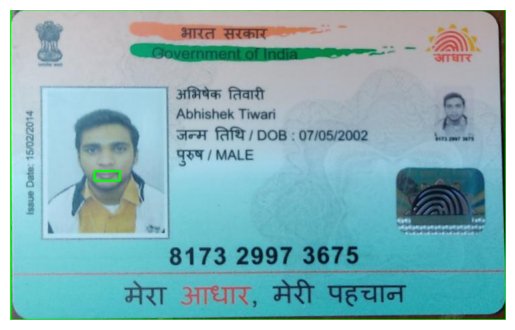

In [ ]:
# # Use pytesseract to detect text and its bounding boxes
# data = pytesseract.image_to_data(gray_contour_id, config=custom_config, output_type=pytesseract.Output.DICT)

# # Iterate through each detected text item
# for i in range(len(data['text'])):
#     if int(data['conf'][i]) > 60:  # Only consider boxes with a confidence > 60
#         x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
#         cv2.rectangle(contour_id, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Draw rectangle with green color and 2 px thickness

# # Display the image with bounding boxes
# plt.imshow(contour_id)
# plt.axis('off')
# plt.show()

In [ ]:
# data['text']

### OCR using PaddleOCR

Due to its high accuracy and good speed, CRNN is an optimal choice for OCR. Latest libraries like Easy-ocr, Keras-ocr and PaddleOCR are based on CRNN and provide easy-to-use pretrained models. 

PaddleOCR supports more than 80 languages (depending upon the OCR algorithm used). But the flagship PP-OCR provides support for both Chinese and English languages. The flagship OCR algorithm PP-OCR is one of the best OCR tools available. So far, It has three versions as of now PP-OCR, PP-OCRv2 and PP-OCRv3. All of these models are built on CRNN as seen in the previous section and are ultra-lightweight. Let’s take a look and apply it to some of the various types of scenarios. 

`PaddleOCR Initialization Parameters`

use_angle_cls=True: This parameter tells PaddleOCR to use angle classification, which is useful when the text in the images could be oriented in different directions. With use_angle_cls set to True, the model will attempt to correct the orientation of the text before recognizing it, which generally improves the accuracy of text recognition.

use_gpu=False: This parameter specifies whether to use a GPU for processing. Setting use_gpu=False forces the tool to use the CPU instead. Using the GPU can significantly speed up OCR processing, especially for large volumes of images or high-resolution images, but it requires a compatible GPU and proper configuration. Setting it to False is useful if you are running the software on a system without a GPU or you want to ensure compatibility without requiring GPU resources.

In [ ]:
# from paddleocr import PaddleOCR, draw_ocr
# %matplotlib inline

# ocr = PaddleOCR(use_angle_cls=True, use_gpu=False)


# def show_ocr(ocr, img_path, font):

#     result = ocr.ocr(img_path)
#     # save_path = os.path.join(out_path, img_path.split('/')[-1] + 'output')

#     image = cv2.imread(img_path)

#     boxes = [line[0] for line in result[0]]
#     txts = [line[1][0] for line in result[0]]
#     scores = [line[1][1] for line in result[0]]

#     im_show = draw_ocr(image, boxes, txts, scores, font_path=font)

#     # cv2.imwrite(save_path, im_show)

#     img = cv2.cvtColor(im_show, cv2.COLOR_BGR2RGB)
#     plt.imshow(img)	
#     plt.axis('off')
#     # return result

In [ ]:
# img_path = 'A:/CODES/PROJECTS/eKYC/data/personal/sample_image1.jpg'
# font = "A:\CODES\PROJECTS\eKYC\models\simfang.ttf"
# show_ocr(ocr, img_path, font)

### Keras OCR

In [ ]:
# import keras_ocr

# pipeline = keras_ocr.pipeline.Pipeline()
# # Read images from folder path to image object
# images = [
#     keras_ocr.tools.read(img) for img in ['A:/CODES/PROJECTS/eKYC/data/raw_data/pan_2.jpg',
#                                           'A:/CODES/PROJECTS/eKYC/data/raw_data/pan_3.webp',
#                                           'A:/CODES/PROJECTS/eKYC/data/personal/sample_image1.jpg']
# ]

3/3 [==============================] - 7s 1s/step


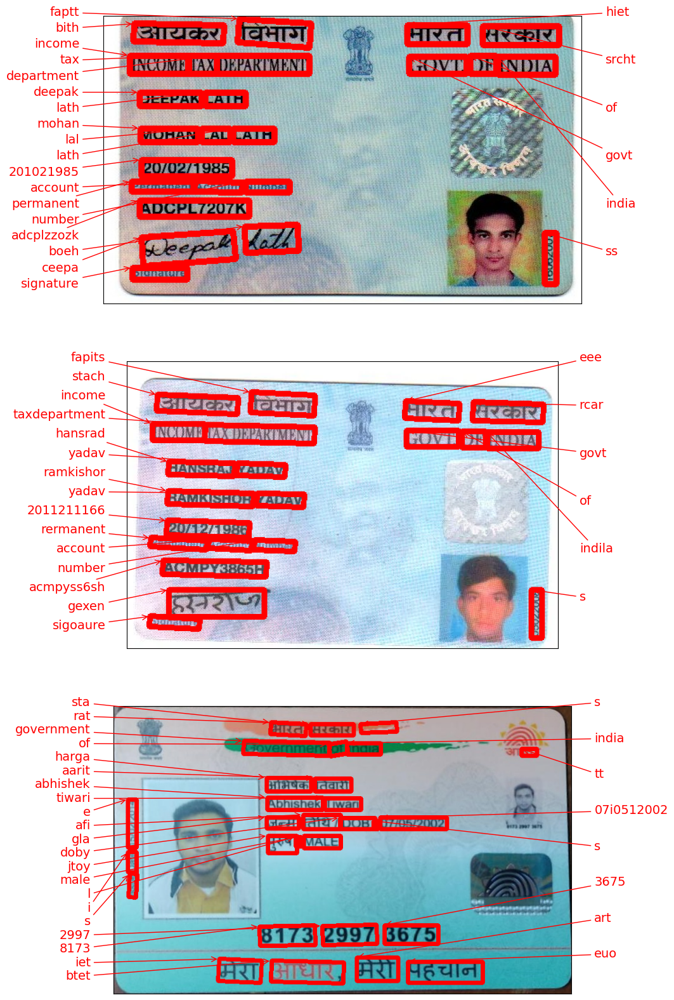

In [ ]:
# # generate text predictions from the images
# prediction_groups = pipeline.recognize(images)

# # plot the text predictions
# fig, axs = plt.subplots(nrows=len(images), figsize=(10, 20))
# for ax, image, predictions in zip(axs, images, prediction_groups):
#     keras_ocr.tools.drawAnnotations(image=image, 
#                                     predictions=predictions, 
#                                     ax=ax)

In [ ]:
# prediction_groups

### Using easyOCR

In [ ]:
reader = easyocr.Reader(['en'])
result = reader.readtext(contour_id)
result

In [ ]:
countour_copy =  np.copy(contour_id)

for detection in result:
    bounding_box = detection[0]
    recognized_text = detection[1]
    confidence = detection[2]
    
    # Convert the bounding box points to integers
    x_min, y_min = map(int, bounding_box[0])
    x_max, y_max = map(int, bounding_box[2])
    
    # Draw a rectangle around the text
    cv2.rectangle(countour_copy, (x_min, y_min), (x_max, y_max), (0, 0, 155), 2)
    
    # Put the recognized text on the image
    cv2.putText(countour_copy, recognized_text, (x_min, y_min - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (155, 0, 0), 2)

plt.imshow(countour_copy)
plt.axis('off')
plt.show()

In [ ]:
confidence_threshold =  .80
filtered_text = ""  # Initialize an empty string to store filtered text
for text in result:
    bounding_box, recognized_text, confidence = text
    if confidence > confidence_threshold:
        filtered_text += recognized_text + "|"  # Append filtered text with newline

filtered_text